# S. Appendix

### Appendix S.1 Additional Experimental Setups

In this study, the model design and training process followed the research procedures described in previous studies [1,2]. To ensure fair comparisons among all experiments, a consistent network architecture and training configuration were maintained across all methods. Unless otherwise specified, the Physics-Informed Deep Operator Network model comprises a Trunk Network, a Branch Network, and a Gating Network, each containing five hidden layers with 256 neurons per layer and employing the GELU activation function. The network parameters were initialized using the default scheme in PyTorch.

The loss function follows the PIDoN formulation, in which weights are assigned to the data-fitting, ODE residual, and initial condition terms. The experimental validation was performed by measuring the volumetric flowrate.

$$
\hat{q}(t) \approx G_\theta [v](t) \approx \psi(v,t;\theta^*)
\tag{S.1}
$$

$$
L_{\mathrm{Data}} = \frac{1}{N_t} \sum_{i=1}^{N_t} \left[\hat{q}(t_i)-q(t_i)\right]^2,
$$

$$
L_{\mathrm{Res}} = \frac{1}{N_t} \sum_{i=1}^{N_t} \left[\left\{L\ddot{q}(t_i)+R\dot{q}(t_i)+\frac{1}{C}q(t_i)\right\}-F U_A(t_i)\right]^2,
$$

$$
L_{\mathrm{Init}} = \left[q(t_0)-0\right]^2 + \left[L\dot{q}(t_0)-0\right]^2
\tag{S.2}
$$

The total loss is defined as:

$$
L_{\mathrm{Tot}} = \lambda_{\mathrm{Data}} L_{\mathrm{Data}} + \lambda_{\mathrm{Res}} L_{\mathrm{Res}} + \lambda_{\mathrm{Init}} L_{\mathrm{Init}}
\tag{S.3}
$$

where $L_{\mathrm{Data}}$, $L_{\mathrm{Res}}$, and $L_{\mathrm{Init}}$ represent the mean squared errors corresponding to the training data, ODE residual, and initial condition, respectively. To adequately enforce the data-fitting constraint, the weighting factors were set to $\lambda_{\mathrm{Data}} = 10^6$, $\lambda_{\mathrm{Res}} = 10^6$, and $\lambda_{\mathrm{Init}} = 10^3$. The optimization was performed using the Adam optimizer with an applied learning-rate scheduling strategy. The data sampling was conducted using a PIDoN mesh-free approach, employing collocation points distributed throughout the entire computational domain. For the time-dependent problem, the training data were measured at 1 $\mu$s intervals over a total duration of 300 $\mu$s. The ODE residual was also evaluated through temporal sampling over the same time interval. To enforce the initial condition, collocation points were sampled at $t_0 = 0$ to impose the initial condition.

In this section, we provide a detailed description of the Deep Operator Network (DoN) architecture, a systematic methodology for domain-specific feature extraction, parameter initialization, normalization techniques, and the overall operational workflow. The integrated PIDoN model is designed to solve the ODE by incorporating learnable feature mappings and domain-specific knowledge into the neural network framework. To ensure statistical significance, each parameter identification was repeated five times with different random seeds.

The DoN employed in this study consists of three primary components: the Branch Network, the Trunk Network, and an auxiliary Gating Network. The architecture is summarized as follows:

- **Branch Network:** 5 hidden layers, each with 256 neurons and GELU activation, mapping input parameters to a latent representation.
- **Trunk Network:** 5 hidden layers, each with 256 neurons and GELU activation, mapping temporal input to a latent representation.
- **Gating Network:** 5 hidden layers, each with 256 neurons and GELU activation, followed by a sigmoid activation to provide gating modulation over the latent space.
- **Latent Dimension:** Each network outputs a latent vector of dimension 32.
- **Output Layer:** The final operator output is obtained by an element-wise product of Branch, Trunk, and Gating Network outputs, followed by summation and a learnable bias term.

---

### S.2 Physics-Informed Deep Operator Network modeling

The Deep Operator Network (DoN) is an artificial neural network architecture for operator learning, which aims to map an entire input function to a target function (Lu et al., 2021). In this framework, the operator is approximated via inner-product fusion between the Branch Network (processing sampled input-function values) and the Trunk Network (processing output-domain coordinates) (Li et al., 2020). By the universal approximation theorem for operators, DoN can approximate nonlinear operators to arbitrary accuracy, enabling modeling of complex physical systems and inverse problems (Chen and Chen, 1995; Lu et al., 2021).

To achieve this, an input function $v$ in an infinite-dimensional space is discretized into $N$ samples, yielding a finite-dimensional vector:
$$
\mathbf{v} = [v(t_1),\, v(t_2),\, v(t_3),\, \ldots,\, v(t_N)]^{\top} \in \mathbb{R}^{N}.
\tag{S.4}
$$

The input vector $\mathbf{v}$ is passed through a feed-forward neural network (the Branch Network) to generate a latent representation parameterized by $\theta_B$:
$$
B(\mathbf{v}) = \mathcal{N}_{\mathrm{Branch}}(\mathbf{v}; \theta_B) \in \mathbb{R}^{l}.
\tag{S.5}
$$

The Branch Network updates each hidden layer during training according to:
$$
\mathbf{h}^{(k+1)} = z\!\left(W^{(k)} \mathbf{h}^{(k)} + \mathbf{b}^{(k)}\right),
\qquad k = 0,1,\ldots,n-1,
\tag{S.6}
$$
where $z(\cdot)$ denotes the activation function and $\mathbf{b}^{(k)}$ is the bias vector.

The Trunk Network takes the output-domain coordinates $t$ as input and generates the latent vector at each location:
$$
T(t) = \mathcal{N}_{\mathrm{Trunk}}(t; \theta_T) \in \mathbb{R}^{l}.
\tag{S.7}
$$

Each hidden layer of the Trunk Network is updated as:
$$
\mathbf{h}^{(s+1)} = z\!\left(W^{(s)} \mathbf{h}^{(s)} + \mathbf{b}^{(s)}\right),
\qquad s = 0,1,\ldots,n-1.
\tag{S.8}
$$

The set of trainable parameters in both networks is:
$$
\theta =
\left\{
\{W_B^{(k)}\},\, \{\mathbf{b}_B^{(k)}\},\, \{W_T^{(s)}\},\, \{\mathbf{b}_T^{(s)}\}
\right\}_{(l,s)}.
\tag{S.9}
$$

The predictive function generated by the operator is given by the inner product of Branch and Trunk features:
$$
\psi(\mathbf{v}, t; \theta)
=
\langle B(\mathbf{v}), T(t) \rangle + b_0
=
\sum_{j=1}^{l} B_j(\mathbf{v})\, T_j(t) + b_0,
\tag{S.10}
$$
where $b_0$ is the bias term.

Consequently, the operator of the Deep Operator Network is represented as:
$$
G[v](t) \approx \psi(\mathbf{v}, t; \theta^{*}),
\tag{S.11}
$$
where $\theta^{*}$ denotes the optimized network parameters.

The predicted output $q(t)$ is governed by the ODE:
$$
\dot{q}(t) + \mathcal{N}[q(t), t] = 0,
\qquad t \in (0, t_{\mathrm{fin}}].
\tag{S.12}
$$

Upon receiving the input function $v$, the network returns the solution $q(t,\cdot)$ over the temporal domain. The objective of the Physics-Informed Deep Operator Network (PIDoN) is to approximate and learn this operator using the neural representation $\psi(\mathbf{v}, t; \theta^{*})$.

The total cost formulation is expressed as:
$$
\nabla_{\theta} L_{\mathrm{Tot}}
=
\sum_{s} \delta_{s}\, \nabla_{\theta}\, \psi(\mathbf{v}, t; \theta),
\tag{S.13}
$$
where $\delta_s$ denotes the weighted contribution of each loss component.

Finally, the objective is to determine the optimal parameter set that minimizes the total loss:
$$
\theta^{*} = \arg\min_{\theta}\, L_{\mathrm{Tot}}(\theta).
\tag{S.14}
$$

---


### S.3 Parameter identification modeling

In the present work, parameter identification is formulated as a linear inverse problem driven by the PIDoN outputs (Lu, 2021; Chen, 1995). Given the PIDoN prediction $\hat{q}(t)$ and its time derivatives, a regressor is constructed to map unknown physical parameters to the measured driving voltage $\mathrm{d}U_A/\mathrm{d}t$. Let $m$ be the number of observation instants and $k$ the number of unknown parameters (Kovachki, 2021). Define the regressor matrix $\Phi \in \mathbb{R}^{m \times k}$, the parameter vector $W_{\mathrm{PI}} \in \mathbb{R}^{k}$, and the target vector $\mathbf{f} \in \mathbb{R}^{m}$ (Li, 2020). The baseline identification is written as:
$$
\Phi W_{\mathrm{PI}} = \mathbf{f}.
\tag{S.15}
$$

In the PIDoN framework, the regressor is generated from the neural-operator outputs as:
$$
\hat{\mathbf{q}}(t) =
\begin{bmatrix}
q(t)\\
\dot{q}(t)\\
\ddot{q}(t)
\end{bmatrix},
\qquad
\mathbf{P} =
\begin{bmatrix}
R\\
L\\
C\\
F
\end{bmatrix}
\in \mathbb{R}^{k}.
\tag{S.16}
$$

The operator-induced regressor and the measured actuation vector are defined by:
$$
G(\hat{\mathbf{q}};\theta) \in \mathbb{R}^{m \times k},
\qquad
\mathbf{U}_A =
\begin{bmatrix}
U_A(t_1)\\
\vdots\\
U_A(t_m)
\end{bmatrix}
\in \mathbb{R}^{m}.
\tag{S.17}
$$

Then, the parameter identification model can be written as:
$$
G(\hat{\mathbf{q}};\theta)\,\mathbf{P} = \mathbf{U}_A.
\tag{S.18}
$$

To estimate the unknown parameters, the least-squares principle is adopted:
$$
\min_{W_{\mathrm{PI}} \in \mathbb{R}^{k}}
\left\lVert \Phi W_{\mathrm{PI}} - \mathbf{f} \right\rVert_2^2.
\tag{S.19}
$$

The analytical solution is obtained from the normal equation:
$$
W_{\mathrm{PI}}^{*} = (\Phi^{\top}\Phi)^{-1}\Phi^{\top}\mathbf{f}.
\tag{S.20}
$$

For a gradient-based update, define the least-squares cost:
$$
J(W_{\mathrm{PI}}) = \frac{1}{2}\left\lVert \Phi W_{\mathrm{PI}} - \mathbf{f} \right\rVert_2^2.
\tag{S.21}
$$

Taking the gradient with respect to $W_{\mathrm{PI}}$ yields:
$$
\nabla_{W_{\mathrm{PI}}} J(W_{\mathrm{PI}})
=
\Phi^{\top}(\Phi W_{\mathrm{PI}} - \mathbf{f}).
\tag{S.22}
$$

To incorporate physical constraints, the residual of the governing equation is introduced as the PIDoN physics loss. At each time instant $t$, the residual is expressed as:
$$
r_{\theta}(t;\mathbf{P})
=
L\,\ddot{q}_{\theta}(t)
+
R\,\dot{q}_{\theta}(t)
+
\frac{1}{C}q_{\theta}(t)
-
F\,\dot{U}_A(t).
\tag{S.23}
$$

The physics residual loss is computed as the mean-squared residual over $N_t$ temporal collocation points:
$$
L_{\mathrm{Res}}(\theta,\mathbf{P})
=
\frac{1}{N_t}\sum_{i=1}^{N_t}\left[r_{\theta}(t_i;\mathbf{P})\right]^2.
\tag{S.24}
$$

The parameter updates are performed through backpropagation of the total loss:
$$
\nabla_{\theta} L_{\mathrm{Tot}}
=
\sum_{s}\delta_s\,\nabla_{\theta}\,\psi(\mathbf{v},t;\theta).
\tag{S.25}
$$

The trainable parameter set includes both neural network weights and the physical coefficients:
$$
\theta =
\left[W^{(l)},\, b^{(l)},\, W^{(s)},\, b^{(s)},\, R,\, L,\, C,\, F \right]_{(l,s)}.
\tag{S.26}
$$

The gradients of each loss term with respect to $\theta$ are:
$$
\nabla_{\theta} L_{\mathrm{Data}}
=
\frac{2\lambda_{\mathrm{Data}}}{N_t}\sum_{i=1}^{N_t}
\left[
\frac{\partial q_{\theta}(t_i)}{\partial \theta}\,
\left(q_{\theta}(t_i)-\hat{q}(t_i)\right)
\right],
$$

$$
\nabla_{\theta} L_{\mathrm{Res}}
=
\frac{2\lambda_{\mathrm{Res}}}{N_t}\sum_{i=1}^{N_t}
\left[
\frac{\partial r_{\theta}(t_i;\mathbf{P})}{\partial \theta}\,
r_{\theta}(t_i;\mathbf{P})
\right],
$$

$$
\nabla_{\theta} L_{\mathrm{Init}}
=
2\lambda_{\mathrm{Init}}
\left[
\frac{\partial q_{\theta}(t_0)}{\partial \theta}\,
\left(q_{\theta}(t_0)-0\right)
\right]
+
2\lambda_{\mathrm{Init}}
\left[
\frac{\partial \dot{q}_{\theta}(t_0)}{\partial \theta}\,
\left(L\dot{q}_{\theta}(t_0)-0\right)
\right].
\tag{S.27}
$$

The total composite loss function is:
$$
L_{\mathrm{Tot}}(\theta,\mathbf{P})
=
\lambda_{\mathrm{Data}}L_{\mathrm{Data}}
+
\lambda_{\mathrm{Res}}L_{\mathrm{Res}}
+
\lambda_{\mathrm{Init}}L_{\mathrm{Init}}.
\tag{S.28}
$$

At each iteration, the physical coefficients are updated in the direction that minimizes the total loss:
$$
(\hat{R},\hat{L},\hat{C},\hat{F})
\leftarrow
(R^{*},L^{*},C^{*},F^{*})
-
\eta\,\frac{\partial L_{\mathrm{Tot}}}{\partial \theta}.
\tag{S.29}
$$
where $\eta$ denotes the learning rate.

The final optimal set of parameters is obtained by minimizing the total loss with respect to both the neural parameters $\theta$ and the physical parameters $\mathbf{P}$:
$$
(\theta^{*}, \mathbf{P}^{*})
=
\arg\min_{\theta,\mathbf{P}}
L_{\mathrm{Tot}}(\theta,\mathbf{P}).
\tag{S.30}
$$

Through this framework, the present study proposes an operating-condition analysis method based on inversely identified material properties under varying ink-property and voltage conditions. Because this approach reflects the physical relationship between actuator driving conditions, material properties, and the interfacial volumetric flowrate response, it can be used as an effective criterion for real-time monitoring and interpretation of droplet formation behavior. Furthermore, the transient interfacial response was transformed into representative dynamic-response parameters, enabling a more systematic analysis of time-dependent droplet behavior. Therefore, the proposed inverse Physics-Informed DeepONet framework provides a practical basis for analyzing operating conditions and evaluating droplet formation stability in piezoelectric inkjet systems.

---
---

# Data acquisition

In this study, the experimentally measured interfacial displacement was obtained to secure the data acquisition. To ensure the reliability of the physical trends, physical validation was performed under the same conditions as those used in the experiments. The configuration of the experimental measurement system is presented below.

<div align="center">
  <img src="Fig 1..jpg" alt="Experiment setup" width="1000"><br>
  Fig. 1. Experimental setup: (a) actual experimental system and (b) schematic diagram of the experimental procedure.
</div>

- The developed Inverse Physics-Informed Deep Operator Network model predicts the volumetric flow rate and estimates real-time material property conditions based on the ink properties, voltage waveform, and operating conditions.

- For this purpose, six types of ethylene glycol (EG) were used in the experiments to define the ink property conditions.

- The volumetric flow rate was determined by measuring the flow displacement at the nozzle interface under driving voltages ranging from 20 to 40 V.

- This approach enabled the establishment of precise operating conditions by validating the physical trends observed in the actual experiments.

<div align="center">
  <b>Table 1.</b> Physical property conditions of the piezoelectric inkjet
</div>

<div align="center">

| EG     | Surface tension, $\sigma$ [N/m] | Dynamic viscosity, $\mu$ [Pa·s] | Density, $\rho$ [kg/m³] | Piezoelectric coefficient, $\alpha$ [m/V] | Speed of sound, $c$ [m/s] |
| ------ | ------------------------------: | ------------------------------: | ----------------------: | ----------------------------------------: | ------------------------: |
| EG 100 |                          0.0474 |                          0.0157 |                 1114.00 |                                  2.90e-10 |                   1688.00 |
| EG 90  |                          0.0497 |                          0.0105 |                 1101.00 |                                  2.90e-10 |                   1688.00 |
| EG 75  |                          0.0521 |                          0.0064 |                 1081.00 |                                  2.90e-10 |                   1709.38 |
| EG 65  |                          0.0539 |                          0.0049 |                 1070.00 |                                  2.90e-10 |                   1707.98 |
| EG 60  |                          0.0551 |                          0.0041 |                 1072.00 |                                  2.90e-10 |                   1703.27 |
| EG 50  |                          0.0565 |                          0.0030 |                 1056.00 |                                  2.90e-10 |                   1638.21 |

</div>

<div align="center">
  <img src="Fig 2..jpg" alt="Voltage waveform condition" width="1200"><br>
  Fig 2. Voltage waveform condition
</div>

---
---

## Method. Inverse Physics Informed Deep Operator Network 

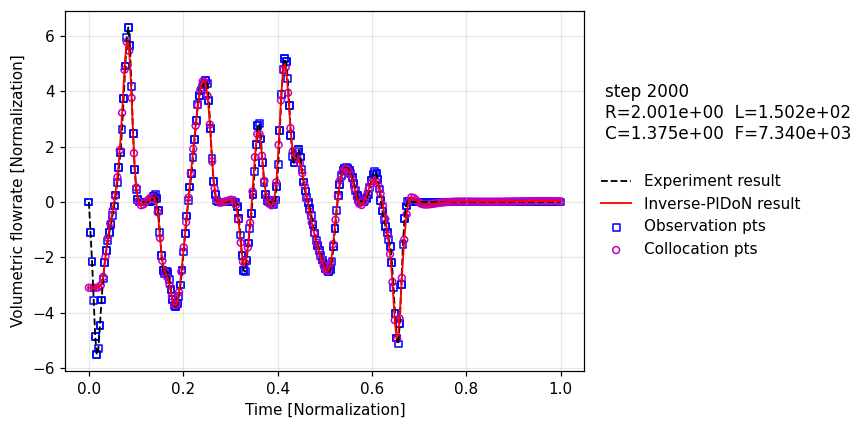

[INFORM] step=2000 | R_est_final=2.001e+00 L_est_final=1.502e+02 | C_est_final=1.375e+00 F_est_final=7.340e+03


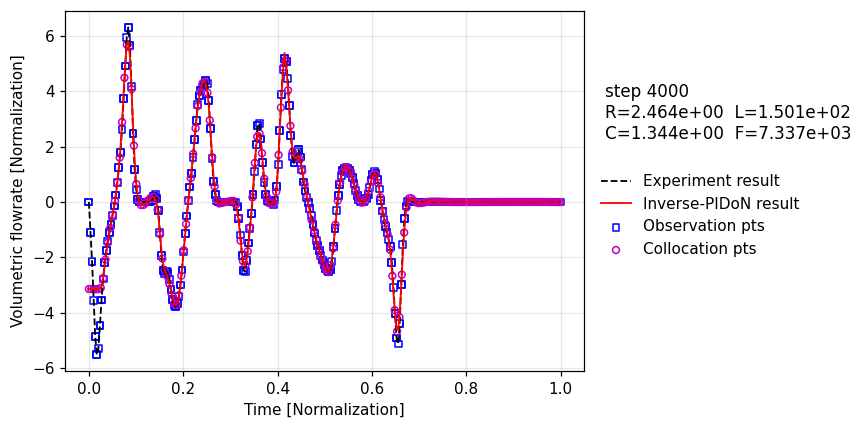

[INFORM] step=4000 | R_est_final=2.464e+00 L_est_final=1.501e+02 | C_est_final=1.344e+00 F_est_final=7.337e+03
  6000 | lr_model 5.00e-07 | lr_R 5.00e-07 | lr_L 5.00e-07 | lr_C 5.00e-07 | lr_F 5.00e-07 | data 1.23e-01 | phys 3.34e+12 | ic 1.02e+01 | R 2.873126e+00 L 1.500410e+02 C 1.334765e+00 F 7.337278e+03


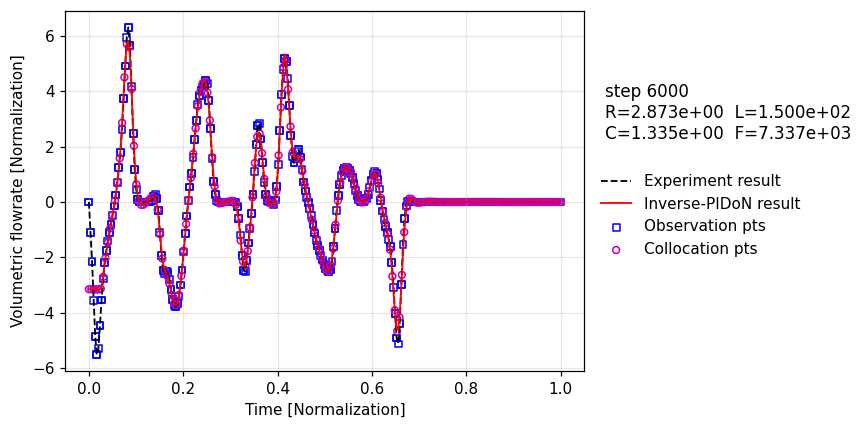

[INFORM] step=6000 | R_est_final=2.873e+00 L_est_final=1.500e+02 | C_est_final=1.335e+00 F_est_final=7.337e+03


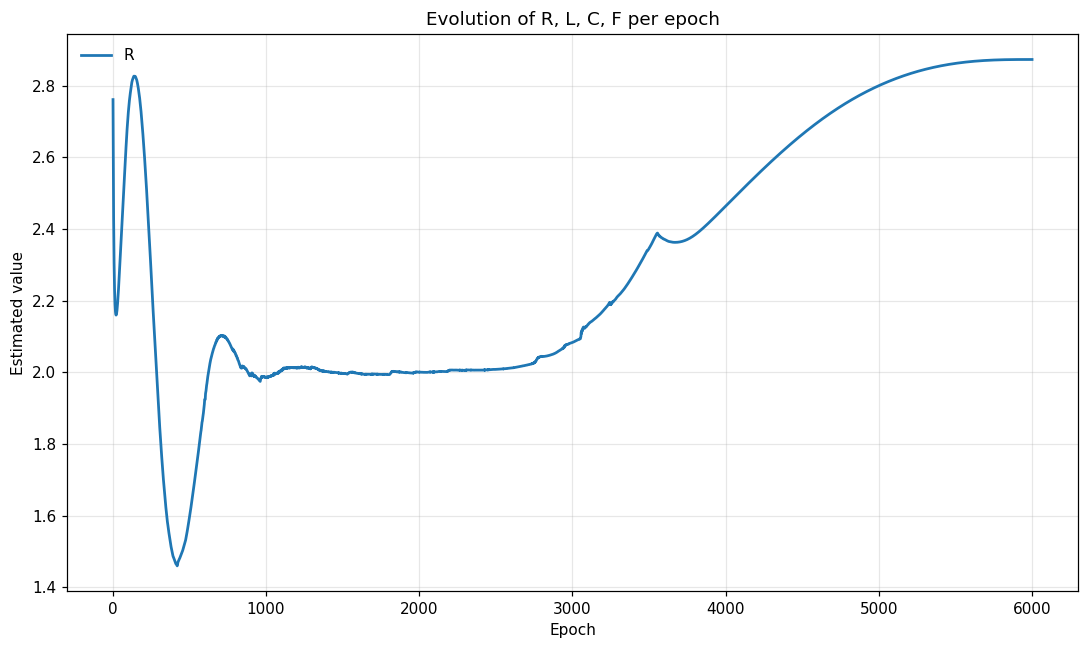

In [325]:
# ═════════════ 0. Library · environment ─══════════════════════════
import math, pandas as pd
from collections import OrderedDict
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os, sys, re

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float32)
plt.rcParams["figure.dpi"] = 110

# ═════════════ 1. External forcing term f_ext(t,F) ─═════════════════════════

"""
               [unit conversion]

# L*q_ddot + R*q_dot + (1/C)*q = F*dU_dt [Pa/s]

# L*q_ddot :  [Pa·s^2/m^3] * [m^3/s^3] = [Pa/s]
# R*q_dot  :  [Pa·s/m^3]   * [m^3/s^2] = [Pa/s]
# (1/C)*q  :  [Pa/m^3]     * [m^3/s]   = [Pa/s]
# F*dU_dt  :  [Pa/V]       * [V/s]     = [Pa/s]
"""

# R      : [Pa·s/m^3]      >      [Pa·us/um^3]
# L      : [Pa·s^2/m^3]    >      [Pa·us^2/um^3]
# C      : [m^3/Pa]        >      [um^3/Pa]
# F      : [Pa/V]          >      [Pa/V]

# q      : [m^3/s]         >      [um^3/us]
# q_dot  : [m^3/s^2]       >      [um^3/us^2]
# q_ddot : [m^3/s^3]       >      [um^3/us^3]

# dU_dt  : [V/s]           >      [V/us]

# Ω_time ⊂ [0, 3e-4] > Ω_time ⊂ [0, 1]
Norm_T = 3e-4
t1_phys, t2_phys, t3_phys, V_max = 6e-6, 26e-6, 32e-6, 24
t1 = t1_phys / Norm_T          # [-]
t2 = t2_phys / Norm_T          # [-]
t3 = t3_phys / Norm_T          # [-]

#   Time-axis remapping (value-preserving):
#   T = t / Norm_T,  t ∈ [0, Norm_T]  ⇔  T ∈ [0, 1]
#   f_val(T) := f_val_phys(t) with t = Norm_T·T  (i.e., f_val(T) = f_val_phys(Norm_T·T); numerical values are preserved under the reparameterization)

def f_ext(t, F_gain):  # f_ext [Pa/s]
    f_val = (
        V_max/t1 * (1 - (t > (t1)).float())
        - V_max/(t3 - t2) * ((t > (t2)).float() - (t > (t3)).float())
    )
    return F_gain * (f_val * Norm_T)   # F_gain = F [Pa/V], f_val = dU_dt [V/s] ; f_ext [Pa/s] = F_gain*f_val/Norm_T [Pa/V]*[V/s]/[us] ; recover the original f_ext value '(f_val*Norm_T)'


# ═════════════ 2. Experimental CSV → training·validation set ─══════════════════
"""
n_full : number of points in the full waveform (uniform grid over [0, t_end])
t_full : full time grid of size (n_full, 1)
y_full : full measured flowrate waveform sampled at t_full (shape: (n_full, 1))

n_data : number of supervised data points subsampled from the full waveform (within data_range)
x_data : selected time locations for data loss (t_full indexed by idx), shape: (n_data, 1)
y_data : selected measured values corresponding to x_data, shape: (n_data, 1)
"""
def load_experiment_csv(csv_path, t_end=1.0, n_full=300,
                        data_range=(0.0, 1.0), n_data=500):
    df     = pd.read_csv(csv_path)
    vals   = df.iloc[0, :n_full].astype(np.float32).to_numpy()
    y_full = torch.from_numpy(vals).view(-1, 1).to(DEVICE)
    t_full = torch.linspace(0.0, t_end, n_full, device=DEVICE).view(-1, 1)

    s, e = (int(data_range[0]/t_end*(n_full-1)),
            int(data_range[1]/t_end*(n_full-1)))
    idx  = torch.linspace(s, e, n_data, dtype=torch.long, device=DEVICE)
    return t_full, y_full, t_full[idx], y_full[idx]

csv_path = r"D:\Code review\Parameter identification\EG 90\3. EG90_24V.csv"
t_full, y_full, x_data, y_data = load_experiment_csv(csv_path)


# ═════════════ 3. PIDoN + g-Net ─═════════════════════════════
class PIDoN(nn.Module):
    def __init__(self, latent: int = 32):
        super().__init__()

        self.branch = nn.Sequential(OrderedDict([
            ("b1", nn.Linear(4,   256)), ("a1", nn.GELU()),
            ("b2", nn.Linear(256, 256)), ("a2", nn.GELU()),
            ("b3", nn.Linear(256, 256)), ("a3", nn.GELU()),
            ("b4", nn.Linear(256, 256)), ("a4", nn.GELU()),
            ("b5", nn.Linear(256, 256)), ("a5", nn.GELU()),
            ("b6", nn.Linear(256, 256)), ("a6", nn.GELU()),
            ("bout", nn.Linear(256, latent))
        ]))

        self.trunk = nn.Sequential(OrderedDict([
            ("t1", nn.Linear(1,   256)), ("a1", nn.GELU()),
            ("t2", nn.Linear(256, 256)), ("a2", nn.GELU()),
            ("t3", nn.Linear(256, 256)), ("a3", nn.GELU()),
            ("t4", nn.Linear(256, 256)), ("a4", nn.GELU()),
            ("t5", nn.Linear(256, 256)), ("a5", nn.GELU()),
            ("t6", nn.Linear(256, 256)), ("a6", nn.GELU()),
            ("tout", nn.Linear(256, latent))
        ]))

        self.g_net = nn.Sequential(OrderedDict([
            ("g1", nn.Linear(1,   256)), ("a1", nn.GELU()),
            ("g2", nn.Linear(256, 256)), ("a2", nn.GELU()),
            ("g3", nn.Linear(256, 256)), ("a3", nn.GELU()),
            ("g4", nn.Linear(256, 256)), ("a4", nn.GELU()),
            ("g5", nn.Linear(256, 256)), ("a5", nn.GELU()),
            ("g6", nn.Linear(256, 256)), ("a6", nn.GELU()),
            ("gout", nn.Linear(256, latent))
        ]))

        self.bias = nn.Parameter(torch.zeros(1, 1, dtype=torch.get_default_dtype()))

    def forward(self, t: torch.Tensor, params: torch.Tensor) -> torch.Tensor:
        B = self.branch(params)            # [B, latent]
        T = self.trunk(t)                  # [B, latent]
        G = torch.sigmoid(self.g_net(t))   # [B, latent]
        return torch.sum(B * T * G, dim=1, keepdim=True) + self.bias


model = PIDoN(latent=32).to(DEVICE)

# ═════════════ 4. Estimated parameters (bounded interval + oscillation damping) ─══════════════
R_MIN, R_MAX = 0.5, 5.0  # (0.5, 3.0)
L_MIN, L_MAX = 150, 350  # (150, 350)
C_MIN, C_MAX = 1.0, 1.8  # (1.0, 1.75)
F_MIN, F_MAX = 6900, 8000  # (6900, 8000)

# Trainable raw variables
L_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
R_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
C_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
F_raw = nn.Parameter(torch.zeros(1, device=DEVICE))


def bound_osc(raw, lo, hi, step: int,
              cur_lr: float, lr_init: float,
              amp0: float, cycles_total: float,
              phase: float = 0.0, amp_power: float = 2.0):
    """
    raw_osc = raw + amp(step) * sin(omega*step + phase)
    amp(step) = amp0 * (cur_lr/lr_init)^amp_power
    theta = sigmoid(raw_osc)  ->  param = lo + (hi-lo)*theta  in [lo, hi]
    """
    amp = amp0 * (max(cur_lr / lr_init, 0.0) ** amp_power)
    omega = 2.0 * math.pi * cycles_total / float(EPOCHS)

    sin_term = torch.sin(torch.tensor(omega * step + phase, device=DEVICE, dtype=raw.dtype))
    raw_osc = raw + amp * sin_term

    return lo + (hi - lo) * torch.sigmoid(raw_osc)

# ═════════════ 5. Loss weights & training setup ─═══════════════════
DATA_WEIGHT = 1e5
PHYS_WEIGHT = 1e-9 # 1e-9
IC_WEIGHT   = 1e2
LR_INIT = 1e-3

t_phys = torch.linspace(0, 1, 200, device=DEVICE).view(-1,1).requires_grad_(True)
t_ic   = torch.tensor([[0.0]], device=DEVICE, requires_grad=True)

# Each parameter has its own update weight
PARAM_UPDATE_WEIGHT = {"model": 1.0, "R": 100.0, "L": 50.0, "C": 50.0, "F": 50.0,}

optim = torch.optim.Adam([
    {"params": model.parameters(), "lr": LR_INIT * PARAM_UPDATE_WEIGHT["model"]},
    {"params": [R_raw],            "lr": LR_INIT * PARAM_UPDATE_WEIGHT["R"]},
    {"params": [L_raw],            "lr": LR_INIT * PARAM_UPDATE_WEIGHT["L"]},
    {"params": [C_raw],            "lr": LR_INIT * PARAM_UPDATE_WEIGHT["C"]},
    {"params": [F_raw],            "lr": LR_INIT * PARAM_UPDATE_WEIGHT["F"]},
])

EPOCHS       = 6_000
PRINT_EVERY  = 6_000
PLOT_EVERY   = 2_000

# Keep the ratio between parameter groups during scheduling
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=EPOCHS, eta_min=LR_INIT*5e-4)

# ═════════════ 5-1. Oscillation hyperparameters ───────────────────────
# amp0: initial oscillation amplitude in raw-space (too large -> unstable swings)
# cycles_total: total number of sine cycles over the entire training
# amp_power: decay rate of the oscillation as lr decreases (typ. 2–4)
# Initial setting: dict(amp0=0.80, cycles_total=25.0, phase=0.0, amp_power=2.5)
OSC_R = dict(amp0=0.95, cycles_total=10, phase=math.pi*2,  amp_power=50)
OSC_L = dict(amp0=0.95, cycles_total=10, phase=math.pi*2,  amp_power=50)
OSC_C = dict(amp0=0.95, cycles_total=10, phase=math.pi*2,  amp_power=50)
OSC_F = dict(amp0=0.95, cycles_total=10, phase=math.pi*2,  amp_power=50)

# ═════════════ 6. Parameter·LR history buffers ─═════════════════════
param_hist = {"epoch": [], "R": [], "L": [], "C": [], "F": []}
lr_hist    = {"epoch": [], "lr_model": [], "lr_R": [], "lr_L": [], "lr_C": [], "lr_F": []}

# ═════════════ 7. Training loop ─═════════════════════════════════
for step in range(1, EPOCHS + 1):
    optim.zero_grad()

    # Use each parameter group's current lr
    cur_lr_R = float(optim.param_groups[1]["lr"])
    cur_lr_L = float(optim.param_groups[2]["lr"])
    cur_lr_C = float(optim.param_groups[3]["lr"])
    cur_lr_F = float(optim.param_groups[4]["lr"])

    # Reconstruct bounded + damped-oscillation parameters
    R_est = bound_osc(R_raw, R_MIN, R_MAX, step, cur_lr_R, LR_INIT * PARAM_UPDATE_WEIGHT["R"], **OSC_R)  # (1,)
    L_est = bound_osc(L_raw, L_MIN, L_MAX, step, cur_lr_L, LR_INIT * PARAM_UPDATE_WEIGHT["L"], **OSC_L)  # (1,)
    C_est = bound_osc(C_raw, C_MIN, C_MAX, step, cur_lr_C, LR_INIT * PARAM_UPDATE_WEIGHT["C"], **OSC_C)  # (1,)
    F_est = bound_osc(F_raw, F_MIN, F_MAX, step, cur_lr_F, LR_INIT * PARAM_UPDATE_WEIGHT["F"], **OSC_F)  # (1,)

    # Model input parameter vector (important: do not use .item() -> keep gradients)
    p_vec = torch.stack([R_est, L_est, C_est, F_est], dim=0).view(1, 4)  # (1,4)

    # (a) Data loss
    """
    y_data, y_phs = q_Norm = q_actual(t) * 1/1000 [um^3/us]
    """
    y_pred_data = model(x_data, p_vec.repeat(x_data.size(0), 1))
    loss_data   = F.mse_loss(y_pred_data, y_data)

    # (b) Physics residual
    """
    # L*q_ddot + R*q_dot + (1/C)*q = F*dU_dt [Pa/s]

    Parameter domain (physical units)
    [LHS]
    - R_est ∈ [0.719e0, 1.716e0]   ([Pa*us/um^3])
    - L_est ∈ [1.606e2, 1.695e2]   ([Pa*us^2/um^3])
    - C_est ∈ [1.442e0, 1.616e0]   ([um^3/Pa])
    [RHS]
    - F_est ∈ [6.994e3, 7.834e3]   ([Pa/V])
    - f_ext = dUdt                 ([Pa/s])

    State/derivatives (time in [us], flowrate in [um^3/us])
    - y_phys = q(t)                ([um^3/us]), with scale approximately -5e4 < q(t) < 5e4
    - dy     = dq/dt               ([um^3/us^2])
    - d2y    = d²q/dt²             ([um^3/us^3])

    # 0) Residual form: each term should have units of [Pa/us]; however, f_ext is in [Pa/s], so a unit conversion is required.
    res = L_est*d2y + R_est*dy + (1.0/C_est)*y_phys - f_ext(t_phys, F_est)

    # 1) f_ext [Pa/s] > [Pa/us]
    res = L_est*d2y + R_est*dy + (1.0/C_est)*y_phys - f_ext(t_phys, F_est) * 1e-6
    # RHS: [Pa/s]*1e-6 = [Pa/us]

    # 2) y_data, y_phs = q_actual(t) * 1/1000 [um^3/us]
    s_q = 1000.0  # q scaling used in data: q_Norm = q_actual / s_q
    res = (L_est*d2y + R_est*dy + (1.0/C_est)*y_phys)*s_q - (f_ext(t_phys, F_est) * 1e-6)
    """
    y_phys = model(t_phys, p_vec.repeat(t_phys.size(0), 1))
    dy  = torch.autograd.grad(y_phys, t_phys, torch.ones_like(y_phys),
                              create_graph=True, retain_graph=True)[0]
    d2y = torch.autograd.grad(dy, t_phys, torch.ones_like(dy),
                              create_graph=True, retain_graph=True)[0]

    s_q = 1e3
    res = (L_est*d2y + R_est*dy + (1.0/C_est)*y_phys) - (f_ext(t_phys, F_est) * 1e-6) / s_q
    loss_phys = res.pow(2).mean()

    # (c) Initial-condition loss
    y0  = model(t_ic, p_vec)
    dy0 = torch.autograd.grad(y0, t_ic, torch.ones_like(y0),
                              create_graph=True, retain_graph=True)[0]
    loss_ic = (y0.pow(2) + dy0.pow(2)).mean()

    # (d) Total loss
    total_loss = (DATA_WEIGHT * loss_data +
                  PHYS_WEIGHT * loss_phys +
                  IC_WEIGHT   * loss_ic)
    total_loss.backward()
    optim.step()
    scheduler.step()

    # (e) Record parameter·LR history
    param_hist["epoch"].append(step)
    param_hist["R"].append(float(R_est.detach().cpu()))
    param_hist["L"].append(float(L_est.detach().cpu()))
    param_hist["C"].append(float(C_est.detach().cpu()))
    param_hist["F"].append(float(F_est.detach().cpu()))

    lr_hist["epoch"].append(step)
    lr_hist["lr_model"].append(float(optim.param_groups[0]["lr"]))
    lr_hist["lr_R"].append(float(optim.param_groups[1]["lr"]))
    lr_hist["lr_L"].append(float(optim.param_groups[2]["lr"]))
    lr_hist["lr_C"].append(float(optim.param_groups[3]["lr"]))
    lr_hist["lr_F"].append(float(optim.param_groups[4]["lr"]))

    if step % PRINT_EVERY == 0:
        print(f"{step:>6} | "
              f"lr_model {optim.param_groups[0]['lr']:.2e} | "
              f"lr_R {optim.param_groups[1]['lr']:.2e} | "
              f"lr_L {optim.param_groups[2]['lr']:.2e} | "
              f"lr_C {optim.param_groups[3]['lr']:.2e} | "
              f"lr_F {optim.param_groups[4]['lr']:.2e} | "
              f"data {loss_data.item():.2e} | "
              f"phys {loss_phys.item():.2e} | "
              f"ic {loss_ic.item():.2e} | "
              f"R {R_est.item():.6e} L {L_est.item():.6e} "
              f"C {C_est.item():.6e} F {F_est.item():.6e}")

    if step % PLOT_EVERY == 0:
        with torch.no_grad():
            y_hat_mid = model(t_full, p_vec.repeat(t_full.size(0), 1)).cpu()
            y_phys_plot = model(t_phys.detach(), p_vec.repeat(t_phys.size(0), 1)).cpu()

        plt.figure(figsize=(8, 4))
        plt.plot(t_full.cpu(), y_full.cpu(), 'k--', lw=1.2, label='Experiment result')
        plt.plot(t_full.cpu(), y_hat_mid, 'r', lw=1.2, label='Inverse-PIDoN result')
        plt.scatter(x_data.cpu(), y_data.cpu(), facecolors='none', edgecolors='b', marker='s', s=20, label='Observation pts')
        plt.scatter(t_phys.detach().cpu(), y_phys_plot, facecolors='none', edgecolors='m', marker='o', s=20, label='Collocation pts')
        plt.xlabel("Time [Normalization]")
        plt.ylabel("Volumetric flowrate [Normalization]")
        plt.grid(alpha=0.3)
        plt.legend(frameon=False, loc=(1.02, 0.30))
        plt.text(1.04, 0.80,
                 f"step {step}\n"
                 f"R={R_est.item():.3e}  L={L_est.item():.3e}\n"
                 f"C={C_est.item():.3e}  F={F_est.item():.3e}\n",
                 transform=plt.gca().transAxes, va='top', fontsize=11)
        plt.tight_layout()
        plt.show()

        R_est_final = float(R_est.detach().cpu())
        L_est_final = float(L_est.detach().cpu())
        C_est_final = float(C_est.detach().cpu())
        F_est_final = float(F_est.detach().cpu())

        print(
            f"[INFORM] step={step} | "
            f"R_est_final={R_est_final:.3e} L_est_final={L_est_final:.3e} | "
            f"C_est_final={C_est_final:.3e} F_est_final={F_est_final:.3e}"
        )


# ═════════════ 8. Visualization of [R, L, C, F] / epoch ─═══════════════
plt.figure(figsize=(10, 6))
plt.plot(param_hist["epoch"], param_hist["R"], label="R", lw=1.8)
#plt.plot(param_hist["epoch"], param_hist["L"], label="L", lw=1.8)
#plt.plot(param_hist["epoch"], param_hist["C"], label="C", lw=1.8)
#plt.plot(param_hist["epoch"], param_hist["F"], label="F", lw=1.8)
plt.xlabel("Epoch")
plt.ylabel("Estimated value")
#plt.yscale("log")
plt.title("Evolution of R, L, C, F per epoch")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [326]:
print(f"R_est_final = {R_est_final:.6e}")
print(f"L_est_final = {L_est_final:.6e}")
print(f"C_est_final = {C_est_final:.6e}")
print(f"F_est_final = {F_est_final:.6e}")

R_est_final = 2.873126e+00
L_est_final = 1.500410e+02
C_est_final = 1.334765e+00
F_est_final = 7.337278e+03


---
---

# Result

In [182]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ═════════════ 1. verify the calculation ══════════════
# ============================================================
# a) Unit conversion (micro-unit system -> SI)
#    NOTE: In this script, C_hat is interpreted as C_nozzle.
# ============================================================
"""
Convert units:
  R_est : [Pa·us/um^3]   -> [Pa·s/m^3]      multiply by 1e12
  L_est : [Pa·us^2/um^3] -> [Pa·s^2/m^3]    multiply by 1e6
  C_est : [um^3/Pa]      -> [m^3/Pa]        multiply by 1e-18   (here: C_est = C_nozzle)
  F_est : [Pa/V]         -> [Pa/V]          unchanged
"""

def micro_to_SI_nozzle(R_est, L_est, C_est, F_est):
    R_SI = float(R_est) * 1e12      # [Pa·s/m^3]
    L_SI = float(L_est) * 1e6       # [Pa·s^2/m^3]
    C_SI = float(C_est) * 1e-18     # [m^3/Pa]   (C_nozzle in SI)
    F_SI = float(F_est)             # [Pa/V]
    return R_SI, L_SI, C_SI, F_SI


# ============================================================
# b) Calculate ink properties assuming C_hat == C_nozzle
#    (infer sigma; c is inferred from F, not from C_channel)
# ============================================================
def infer_ink_properties_from_RLCF_nozzle_only(
    R_est, L_est, C_est, F_est,
    r_m, r_nozz_m, l_tot_m, alpha_m_per_V
):
    # Convert to SI (C_SI is C_nozzle in SI)
    R_SI, L_SI, C_SI, F_SI = micro_to_SI_nozzle(R_est, L_est, C_est, F_est)

    # (i) rho from inertance: L = rho*l/(pi*r^2)
    rho_est = L_SI * math.pi * (r_m**2) / l_tot_m  # [kg/m^3]

    # (ii) c from F (using known alpha): F = 2*rho*c^2*alpha / r
    #      c = sqrt(F*r/(2*rho*alpha))
    c_est = math.sqrt((F_SI * r_m) / (2.0 * rho_est * alpha_m_per_V))  # [m/s]

    # (iii) mu from Stokes boundary-layer resistance model (eliminate delta_v):
    # mu = (R^2 * pi * r^6) / (2 * rho * c * l)
    mu_est = (R_SI**2 * math.pi * (r_m**6)) / (2.0 * rho_est * c_est * l_tot_m)  # [Pa·s]

    # (iv) sigma from nozzle compliance: C_nozzle = pi*r_nozz^4 / (3*sigma)
    #      sigma = pi*r_nozz^4 / (3*C_nozzle)
    sigma_est = math.pi * (r_nozz_m**4) / (3.0 * C_SI)  # [N/m]

    # ---- Consistency checks: recompute R, L, C_nozzle, F ----
    L_verif_SI = rho_est * l_tot_m / (math.pi * (r_m**2))  # [Pa·s^2/m^3]

    T_visc = 2.0 * l_tot_m / c_est  # [s]
    delta_v = math.sqrt(mu_est * T_visc / (math.pi * rho_est))  # [m]
    R_verif_SI = 2.0 * mu_est * l_tot_m / (math.pi * delta_v * (r_m**3))  # [Pa·s/m^3]

    F_verif_SI = 2.0 * rho_est * (c_est**2) * alpha_m_per_V / r_m  # [Pa/V]

    C_verif_SI = math.pi * (r_nozz_m**4) / (3.0 * sigma_est)  # [m^3/Pa] (C_nozzle)

    # Convert predictions back to micro-units
    R_verif_est = R_verif_SI / 1e12         # [Pa·us/um^3]
    L_verif_est = L_verif_SI / 1e6          # [Pa·us^2/um^3]
    C_verif_est = C_verif_SI / 1e-18        # [um^3/Pa]  (C_nozzle)
    F_verif_est = F_verif_SI                # [Pa/V]

    def rel_err(verif, ref):
        ref = float(ref)
        verif = float(verif)
        return np.nan if abs(ref) < 1e-30 else (verif - ref) / ref

    out = {
        "rho_est": rho_est,
        "c_est": c_est,
        "mu_est": mu_est,
        "sigma_est": sigma_est,

        "R_est": float(R_est),
        "L_est": float(L_est),
        "C_est": float(C_est),   # C_hat interpreted as C_nozzle [um^3/Pa]
        "F_est": float(F_est),

        "R_verif_est": float(R_verif_est),
        "L_verif_est": float(L_verif_est),
        "C_verif_est": float(C_verif_est),  # recomputed C_nozzle
        "F_verif_est": float(F_verif_est),

        "relerr_R": rel_err(R_verif_est, R_est),
        "relerr_L": rel_err(L_verif_est, L_est),
        "relerr_C": rel_err(C_verif_est, C_est),
        "relerr_F": rel_err(F_verif_est, F_est),
    }
    return out


# =========================
# c) Relative error: error printing for ink properties
# =========================
def rel_err_pct(est, ref):
    ref = float(ref)
    est = float(est)
    return np.nan if abs(ref) < 1e-30 else 100.0 * (est - ref) / ref

def abs_err(est, ref):
    return float(est) - float(ref)


# =========================
# d) Geometry & Ink property inputs: C_hat must be C_nozzle [um^3/Pa]
# =========================
# R_est_final = ...
# L_est_final = ...
# C_est_final = ...
# F_est_final = ...

alpha = 0.29e-9          # [m/V]
r = 235e-6               # [m] channel radius
r_nozz = 25e-6           # [m] nozzle radius
l1, l2, l3, l4 = 0.012, 0.0084, 0.00542303, 0.00057697
l_tot = l1 + l2 + l3 + l4

sigma_ref = 0.0474        # [N/m]
mu_ref    = 0.0157        # [Pa·s]
rho_ref   = 1114.0       # [kg/m^3]
c_ref     = 1688.2       # [m/s]



result = infer_ink_properties_from_RLCF_nozzle_only(
    R_est_final, L_est_final, C_est_final, F_est_final,
    r_m=r, r_nozz_m=r_nozz, l_tot_m=l_tot, alpha_m_per_V=alpha
)

print("=== Estimated ink properties ===")
print(f"rho_est   = {result['rho_est']:.6f}  [kg/m^3]")
print(f"c_est     = {result['c_est']:.6f}  [m/s]")
print(f"mu_est    = {result['mu_est']:.6e}  [Pa·s]")
print(f"sigma_est = {result['sigma_est']:.6e}  [N/m]")

print("\n=== Ink property error (estimated vs experiment) ===")
print(f"rho  : est = {result['rho_est']:.6f} [kg/m^3]  vs  ref = {rho_ref:.6f} [kg/m^3]  |    rel.err = {rel_err_pct(result['rho_est'], rho_ref):.3e} %")
print(f"c    : est = {result['c_est']:.6f} [m/s]     vs  ref = {c_ref:.6f} [m/s]     |    rel.err = {rel_err_pct(result['c_est'], c_ref):.3e} %")
print(f"mu   : est = {result['mu_est']:.6e} [Pa·s]   vs  ref = {mu_ref:.6e} [Pa·s]   |    rel.err = {rel_err_pct(result['mu_est'], mu_ref):.3e} %")
print(f"sigma: est = {result['sigma_est']:.6e} [N/m]    vs  ref = {sigma_ref:.6e} [N/m]    |    rel.err = {rel_err_pct(result['sigma_est'], sigma_ref):.3e} %")

print("\n=== Consistency check: verify the calculation (recomputed vs inferred, micro-units) ===")
print(f"R_verif = {result['R_verif_est']:.6e}  vs  R_est = {result['R_est']:.6e}  (rel.err={100*result['relerr_R']:.3e} %)")
print(f"L_verif = {result['L_verif_est']:.6e}  vs  L_est = {result['L_est']:.6e}  (rel.err={100*result['relerr_L']:.3e} %)")
print(f"C_verif = {result['C_verif_est']:.6e}  vs  C_est = {result['C_est']:.6e}  (rel.err={100*result['relerr_C']:.3e} %)")
print(f"F_verif = {result['F_verif_est']:.6e}  vs  F_est = {result['F_est']:.6e}  (rel.err={100*result['relerr_F']:.3e} %)")

=== Estimated ink properties ===
rho_est   = 1101.103461  [kg/m^3]
c_est     = 1655.403107  [m/s]
mu_est    = 1.679107e-02  [Pa·s]
sigma_est = 2.921772e-01  [N/m]

=== Ink property error (estimated vs experiment) ===
rho  : est = 1101.103461 [kg/m^3]  vs  ref = 1114.000000 [kg/m^3]  |    rel.err = -1.158e+00 %
c    : est = 1655.403107 [m/s]     vs  ref = 1688.200000 [m/s]     |    rel.err = -1.943e+00 %
mu   : est = 1.679107e-02 [Pa·s]   vs  ref = 1.570000e-02 [Pa·s]   |    rel.err = 6.950e+00 %
sigma: est = 2.921772e-01 [N/m]    vs  ref = 4.740000e-02 [N/m]    |    rel.err = 5.164e+02 %

=== Consistency check: verify the calculation (recomputed vs inferred, micro-units) ===
R_verif = 1.747606e+00  vs  R_est = 1.747606e+00  (rel.err=0.000e+00 %)
L_verif = 1.675508e+02  vs  L_est = 1.675508e+02  (rel.err=0.000e+00 %)
C_verif = 1.400046e+00  vs  C_est = 1.400046e+00  (rel.err=-1.586e-14 %)
F_verif = 7.447248e+03  vs  F_est = 7.447248e+03  (rel.err=1.221e-14 %)


## Result 1 Parameter estimation

| Parameter/Ink | EG 100 | EG 90 | EG 75 | EG 65 | EG 60 | EG 50 |
|---|---:|---:|---:|---:|---:|---:|
| R_ref [Pa·us/um³] | 1.716e+0 | 1.395e+0 | 1.051e+0 | 8.540e-1 | 8.530e-1 | 7.190e-1 |
| R_est [Pa·us/um³] |  |  |  |  |  |  |
| L_ref [Pa·us^2/um³] | 1.695e+2 | 1.675e+2 | 1.644e+2 | 1.628e+2 | 1.631e+2 | 1.606e+2 |
| L_est [Pa·us^2/um³] |  |  |  |  |  |  |
| C_ref [um³/Pa] | 1.442e+0 | 1.460e+0 | 1.450e+0 | 1.467e+0 | 1.472e+0 | 1.616e+0 |
| C_est [um³/Pa] |  |  |  |  |  |  |
| F_ref [Pa/V] | 7.834e+3 | 7.742e+3 | 7.795e+3 | 7.703e+3 | 7.675e+3 | 6.994e+3 |
| F_est [Pa/V] |  |  |  |  |  |  |

## Result 2 Ink property estimation

| Property/Ink | EG 100 | EG 90 | EG 75 | EG 65 | EG 60 | EG 50 |
|---|---:|---:|---:|---:|---:|---:|
| σ_ref [N/m] | 0.0474 | 0.0497 | 0.0521 | 0.0539 | 0.0551 | 0.0565 |
| σ_est [N/m] |  |  |  |  |  |  |
| μ_ref [Pa·s] | 0.0157 | 0.0105 | 0.0064 | 0.0049 | 0.0041 | 0.0030 |
| μ_est [Pa·s] |  |  |  |  |  |  |
| ρ_ref [kg/m³] | 1114.00 | 1101.00 | 1081.00 | 1070.00 | 1072.00 | 1056.00 |
| ρ_est [kg/m³] |  |  |  |  |  |  |
| c_ref [m/s] | 1688.00 | 1688.00 | 1709.38 | 1707.98 | 1703.27 | 1638.21 |
| c_est [m/s] |  |  |  |  |  |  |


## Result 3 Damping parameter estimation

## Result 3 Damping parameter anlaysis

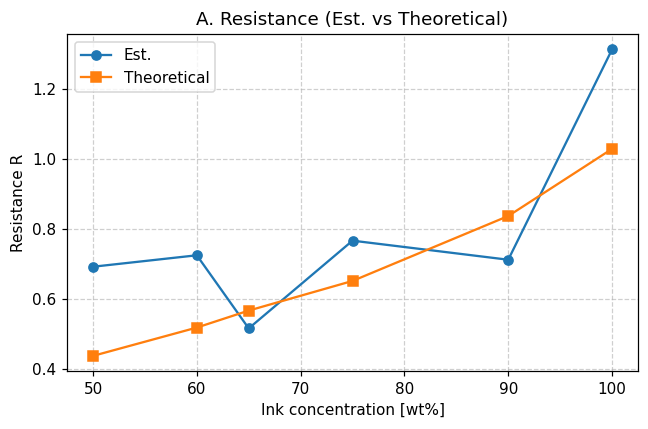

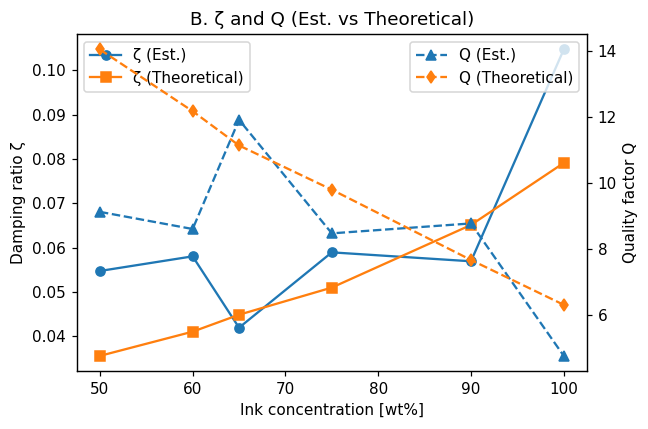

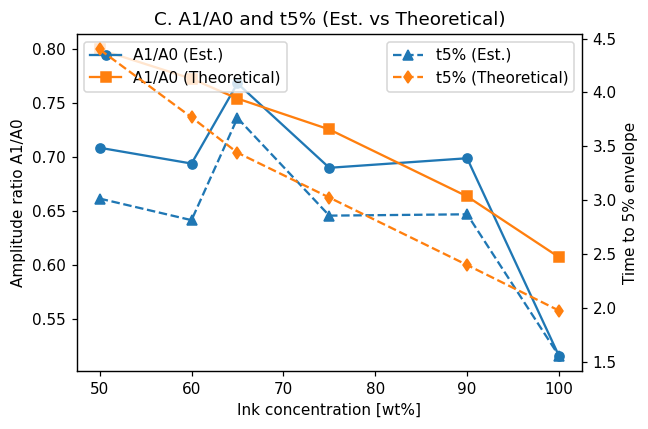

CSV 파일이 저장되었습니다: D:\lsy_DL\Paper result


In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# -----------------------------
# 1) Raw data 입력
# -----------------------------
# (A) 추론값 (Est.)
raw_est = [
    ("EG 100",100, 1.313, 0.3404, 0.008659),
    ("EG 90", 90, 0.7123, 0.3410, 0.008715),
    ("EG 75", 75, 0.7668, 0.3655, 0.008641),
    ("EG 65", 65, 0.5161, 0.3241, 0.008569),
    ("EG 60", 60, 0.7250, 0.3405, 0.008732),
    ("EG 50", 50, 0.6923, 0.3483, 0.008714),
]

# (B) 이론값 (Theoretical)
raw_theo = [
    ("EG 100",100, 1.029, 0.3390, 0.008016),
    ("EG 90", 90, 0.8372, 0.3350, 0.008111),
    ("EG 75", 75, 0.6517, 0.3289, 0.008059),
    ("EG 65", 65, 0.5670, 0.3256, 0.008161),
    ("EG 60", 60, 0.5185, 0.3262, 0.008184),
    ("EG 50", 50, 0.4376, 0.3213, 0.008507),
]

# -----------------------------
# 2) 지표 계산 함수 정의
# -----------------------------
def compute_metrics(raw):
    df = pd.DataFrame(raw, columns=["composition","EG_wt_pct","R","L","C"])
    df = df.sort_values("EG_wt_pct").reset_index(drop=True)
    df["alpha"] = df["R"] / (2.0*df["L"])
    df["omega0"] = 1.0 / np.sqrt(df["L"]*df["C"])
    df["zeta"] = df["alpha"] / df["omega0"]
    df["Q"] = 1.0 / (2.0*df["zeta"])
    tmp = np.maximum(df["omega0"]**2 - df["alpha"]**2, 0.0)
    df["omega_d"] = np.sqrt(tmp)
    df["log_dec"] = 2.0*np.pi*df["zeta"] / np.sqrt(np.maximum(1.0 - df["zeta"]**2, 1e-12))
    df["A1_over_A0"] = np.exp(-df["log_dec"])
    df["t_5pct_envelope"] = np.log(20.0) / df["alpha"]
    df["pole_real"] = -df["alpha"]
    df["pole_imag"] = df["omega_d"]
    return df

df_est  = compute_metrics(raw_est)
df_theo = compute_metrics(raw_theo)

# -----------------------------
# 3) 시각화
# -----------------------------
x = df_est["EG_wt_pct"].values

# (A) Resistance
plt.figure(figsize=(6,4))
plt.plot(x, df_est["R"], marker="o", label="Est.")
plt.plot(x, df_theo["R"], marker="s", label="Theoretical")
plt.xlabel("Ink concentration [wt%]")
plt.ylabel("Resistance R")
plt.title("A. Resistance (Est. vs Theoretical)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# (B) ζ and Q
fig, ax1 = plt.subplots(figsize=(6,4))
ax1.plot(x, df_est["zeta"], marker="o", label="ζ (Est.)")
ax1.plot(x, df_theo["zeta"], marker="s", label="ζ (Theoretical)")
ax1.set_xlabel("Ink concentration [wt%]")
ax1.set_ylabel("Damping ratio ζ")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(x, df_est["Q"], marker="^", linestyle="--", label="Q (Est.)")
ax2.plot(x, df_theo["Q"], marker="d", linestyle="--", label="Q (Theoretical)")
ax2.set_ylabel("Quality factor Q")
ax2.legend(loc="upper right")

plt.title("B. ζ and Q (Est. vs Theoretical)")
plt.tight_layout()
plt.show()

# (C) Amplitude ratio & t5%
fig, ax1 = plt.subplots(figsize=(6,4))
ax1.plot(x, df_est["A1_over_A0"], marker="o", label="A1/A0 (Est.)")
ax1.plot(x, df_theo["A1_over_A0"], marker="s", label="A1/A0 (Theoretical)")
ax1.set_xlabel("Ink concentration [wt%]")
ax1.set_ylabel("Amplitude ratio A1/A0")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(x, df_est["t_5pct_envelope"], marker="^", linestyle="--", label="t5% (Est.)")
ax2.plot(x, df_theo["t_5pct_envelope"], marker="d", linestyle="--", label="t5% (Theoretical)")
ax2.set_ylabel("Time to 5% envelope")
ax2.legend(loc="upper right")

plt.title("C. A1/A0 and t5% (Est. vs Theoretical)")
plt.tight_layout()
plt.show()


# -----------------------------
# 4) CSV 저장
# -----------------------------
save_dir = r"D:\lsy_DL\Paper result"
os.makedirs(save_dir, exist_ok=True)

df_est.to_csv(os.path.join(save_dir, "RLC_metrics_Est.csv"), index=False)
df_theo.to_csv(os.path.join(save_dir, "RLC_metrics_Theoretical.csv"), index=False)

print("CSV 파일이 저장되었습니다:", save_dir)


---

n_data=100 |   2000 | lr 7.50e-04 | total 3.290e+06 | data 3.227e+00 | phys 3.790e+13 | ic 2.493e+03
n_data=100 |   4000 | lr 2.50e-04 | total 1.685e+06 | data 1.633e+00 | phys 4.698e+13 | ic 5.444e+02
n_data=100 |   6000 | lr 5.00e-07 | total 1.184e+06 | data 1.142e+00 | phys 4.090e+13 | ic 1.424e+02
saved: d:\Code review\2025-Rheological Properties-PINN\loss_records_n_data\n_data_100_loss.csv
n_data=200 |   2000 | lr 7.50e-04 | total 7.134e+06 | data 7.129e+00 | phys 2.121e+11 | ic 5.117e+02
n_data=200 |   4000 | lr 2.50e-04 | total 5.978e+06 | data 5.972e+00 | phys 4.325e+11 | ic 5.947e+02
n_data=200 |   6000 | lr 5.00e-07 | total 4.634e+06 | data 4.633e+00 | phys 7.837e+11 | ic 9.094e+01
saved: d:\Code review\2025-Rheological Properties-PINN\loss_records_n_data\n_data_200_loss.csv
n_data=300 |   2000 | lr 7.50e-04 | total 2.777e+06 | data 2.733e+00 | phys 4.328e+13 | ic 5.927e+01
n_data=300 |   4000 | lr 2.50e-04 | total 1.223e+06 | data 1.180e+00 | phys 4.302e+13 | ic 2.815e-01
n_

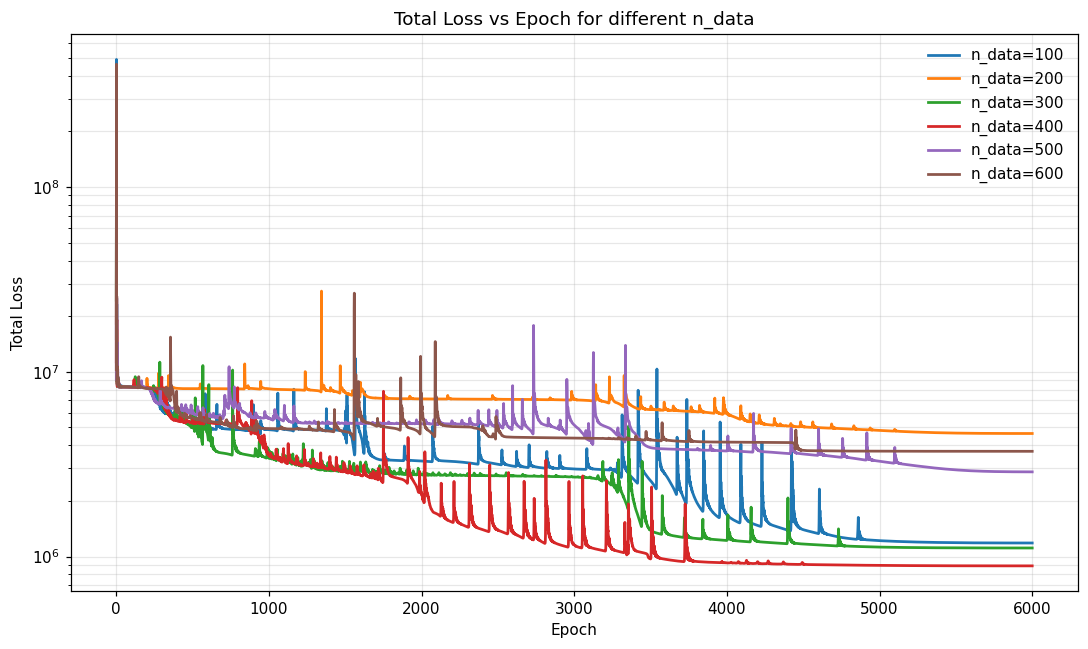

In [71]:
import math
import os
from collections import OrderedDict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float32)
plt.rcParams["figure.dpi"] = 110


Norm_T = 3e-4
t1_phys, t2_phys, t3_phys, V_max = 6e-6, 26e-6, 32e-6, 24
t1 = t1_phys / Norm_T
t2 = t2_phys / Norm_T
t3 = t3_phys / Norm_T


def f_ext(t, F_gain):
    f_val = (
        V_max / t1 * (1 - (t > t1).float())
        - V_max / (t3 - t2) * ((t > t2).float() - (t > t3).float())
    )
    return F_gain * (f_val * Norm_T)


def load_experiment_csv(csv_path, t_end=1.0, n_full=300, data_range=(0.0, 1.0), n_data=600):
    df = pd.read_csv(csv_path)
    vals = df.iloc[0, :n_full].astype(np.float32).to_numpy()
    y_full = torch.from_numpy(vals).view(-1, 1).to(DEVICE)
    t_full = torch.linspace(0.0, t_end, n_full, device=DEVICE).view(-1, 1)
    s = int(data_range[0] / t_end * (n_full - 1))
    e = int(data_range[1] / t_end * (n_full - 1))
    idx = torch.linspace(s, e, n_data, dtype=torch.long, device=DEVICE)
    return t_full, y_full, t_full[idx], y_full[idx]


class PIDoN(nn.Module):
    def __init__(self, latent: int = 32):
        super().__init__()

        self.branch = nn.Sequential(OrderedDict([
            ("b1", nn.Linear(4, 256)), ("ba1", nn.GELU()),
            ("b2", nn.Linear(256, 256)), ("ba2", nn.GELU()),
            ("b3", nn.Linear(256, 256)), ("ba3", nn.GELU()),
            ("b4", nn.Linear(256, 256)), ("ba4", nn.GELU()),
            ("b5", nn.Linear(256, 256)), ("ba5", nn.GELU()),
            ("bout", nn.Linear(256, latent))
        ]))

        self.trunk = nn.Sequential(OrderedDict([
            ("t1", nn.Linear(1, 256)), ("ta1", nn.GELU()),
            ("t2", nn.Linear(256, 256)), ("ta2", nn.GELU()),
            ("t3", nn.Linear(256, 256)), ("ta3", nn.GELU()),
            ("t4", nn.Linear(256, 256)), ("ta4", nn.GELU()),
            ("t5", nn.Linear(256, 256)), ("ta5", nn.GELU()),
            ("tout", nn.Linear(256, latent))
        ]))

        self.g_net = nn.Sequential(OrderedDict([
            ("g1", nn.Linear(1, 256)), ("ga1", nn.GELU()),
            ("g2", nn.Linear(256, 256)), ("ga2", nn.GELU()),
            ("g3", nn.Linear(256, 256)), ("ga3", nn.GELU()),
            ("g4", nn.Linear(256, 256)), ("ga4", nn.GELU()),
            ("g5", nn.Linear(256, 256)), ("ga5", nn.GELU()),
            ("gout", nn.Linear(256, latent))
        ]))

        self.bias = nn.Parameter(torch.zeros(1, 1, dtype=torch.get_default_dtype()))

    def forward(self, t: torch.Tensor, params: torch.Tensor) -> torch.Tensor:
        B = self.branch(params)
        T = self.trunk(t)
        G = torch.sigmoid(self.g_net(t))
        return torch.sum(B * T * G, dim=1, keepdim=True) + self.bias


def bound_osc(raw, lo, hi, step, cur_lr, lr_init, epochs_total, amp0, cycles_total, phase=0.0, amp_power=2.0):
    amp = amp0 * (max(cur_lr / lr_init, 0.0) ** amp_power)
    omega = 2.0 * math.pi * cycles_total / float(epochs_total)
    sin_term = torch.sin(torch.tensor(omega * step + phase, device=DEVICE, dtype=raw.dtype))
    raw_osc = raw + amp * sin_term
    return lo + (hi - lo) * torch.sigmoid(raw_osc)


csv_path = r"D:\Code review\Parameter identification\EG 65\3. EG65_24V.csv"

R_MIN, R_MAX = 0.5, 2.0
L_MIN, L_MAX = 150, 200
C_MIN, C_MAX = 1, 2
F_MIN, F_MAX = 6900, 8000

DATA_WEIGHT = 1e6
PHYS_WEIGHT = 1e-9
IC_WEIGHT = 1e1

LR_INIT = 1e-3
EPOCHS = 6000
PRINT_EVERY = 2000

OSC_L = dict(amp0=0.80, cycles_total=25.0, phase=0.0, amp_power=2.5)
OSC_R = dict(amp0=0.80, cycles_total=25.0, phase=1.2, amp_power=2.5)
OSC_C = dict(amp0=0.80, cycles_total=25.0, phase=2.4, amp_power=2.5)
OSC_F = dict(amp0=0.80, cycles_total=25.0, phase=3.6, amp_power=2.5)

n_data_list = [100, 200, 300, 400, 500, 600]
out_dir = os.path.join(os.getcwd(), "loss_records_n_data")
os.makedirs(out_dir, exist_ok=True)

loss_curves = {}

for n_data in n_data_list:
    t_full, y_full, x_data, y_data = load_experiment_csv(csv_path, n_data=n_data)

    model = PIDoN(latent=32).to(DEVICE)

    L_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
    R_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
    C_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
    F_raw = nn.Parameter(torch.zeros(1, device=DEVICE))

    optim = torch.optim.Adam(list(model.parameters()) + [L_raw, R_raw, C_raw, F_raw], lr=LR_INIT)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=EPOCHS, eta_min=LR_INIT * 5e-4)

    t_phys = torch.linspace(0, 1, 500, device=DEVICE).view(-1, 1).requires_grad_(True)
    t_ic = torch.tensor([[0.0]], device=DEVICE, requires_grad=True)

    hist = {
        "epoch": [],
        "total_loss": [],
        "loss_data": [],
        "loss_phys": [],
        "loss_ic": [],
        "lr": [],
        "L": [],
        "R": [],
        "C": [],
        "F": [],
    }

    for step in range(1, EPOCHS + 1):
        optim.zero_grad()
        cur_lr = float(optim.param_groups[0]["lr"])

        L_hat = bound_osc(L_raw, L_MIN, L_MAX, step, cur_lr, LR_INIT, EPOCHS, **OSC_L)
        R_hat = bound_osc(R_raw, R_MIN, R_MAX, step, cur_lr, LR_INIT, EPOCHS, **OSC_R)
        C_hat = bound_osc(C_raw, C_MIN, C_MAX, step, cur_lr, LR_INIT, EPOCHS, **OSC_C)
        F_hat = bound_osc(F_raw, F_MIN, F_MAX, step, cur_lr, LR_INIT, EPOCHS, **OSC_F)

        p_vec = torch.stack([L_hat, R_hat, C_hat, F_hat], dim=0).view(1, 4)

        y_pred_data = model(x_data, p_vec.repeat(x_data.size(0), 1))
        loss_data = F.mse_loss(y_pred_data, y_data)

        y_phys = model(t_phys, p_vec.repeat(t_phys.size(0), 1))
        dy = torch.autograd.grad(y_phys, t_phys, torch.ones_like(y_phys), create_graph=True, retain_graph=True)[0]
        d2y = torch.autograd.grad(dy, t_phys, torch.ones_like(dy), create_graph=True, retain_graph=True)[0]

        s_q = 1000.0
        res = (L_hat * d2y + R_hat * dy + (1.0 / C_hat) * y_phys) - (f_ext(t_phys, F_hat) * 1e-6) / s_q
        loss_phys = res.pow(2).mean()

        y0 = model(t_ic, p_vec)
        dy0 = torch.autograd.grad(y0, t_ic, torch.ones_like(y0), create_graph=True, retain_graph=True)[0]
        loss_ic = (y0.pow(2) + dy0.pow(2)).mean()

        total_loss = DATA_WEIGHT * loss_data + PHYS_WEIGHT * loss_phys + IC_WEIGHT * loss_ic
        total_loss.backward()
        optim.step()
        scheduler.step()

        hist["epoch"].append(step)
        hist["total_loss"].append(float(total_loss.detach().cpu()))
        hist["loss_data"].append(float(loss_data.detach().cpu()))
        hist["loss_phys"].append(float(loss_phys.detach().cpu()))
        hist["loss_ic"].append(float(loss_ic.detach().cpu()))
        hist["lr"].append(float(optim.param_groups[0]["lr"]))
        hist["L"].append(float(L_hat.detach().cpu()))
        hist["R"].append(float(R_hat.detach().cpu()))
        hist["C"].append(float(C_hat.detach().cpu()))
        hist["F"].append(float(F_hat.detach().cpu()))

        if step % PRINT_EVERY == 0:
            print(
                f"n_data={n_data} | {step:>6} | lr {optim.param_groups[0]['lr']:.2e} | "
                f"total {total_loss.item():.3e} | data {loss_data.item():.3e} | "
                f"phys {loss_phys.item():.3e} | ic {loss_ic.item():.3e}"
            )

    df_hist = pd.DataFrame(hist)
    out_csv = os.path.join(out_dir, f"n_data_{n_data}_loss.csv")
    df_hist.to_csv(out_csv, index=False)
    print(f"saved: {out_csv}")

    loss_curves[n_data] = (df_hist["epoch"].to_numpy(), df_hist["total_loss"].to_numpy())


plt.figure(figsize=(10, 6))
for n_data in n_data_list:
    ep, tl = loss_curves[n_data]
    plt.plot(ep, tl, lw=1.8, label=f"n_data={n_data}")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.yscale("log")
plt.title("Total Loss vs Epoch for different n_data")
plt.grid(alpha=0.3, which="both")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

t_phys=100 |   2000 | lr 7.50e-04 | total 2.820e+06 | data 2.786e+00 | phys 2.175e+13 | ic 1.177e+03
t_phys=100 |   4000 | lr 2.50e-04 | total 1.137e+06 | data 1.117e+00 | phys 1.955e+13 | ic 9.378e+00
t_phys=100 |   6000 | lr 5.00e-07 | total 1.072e+06 | data 1.054e+00 | phys 1.784e+13 | ic 1.153e-01
saved: d:\Code review\2025-Rheological Properties-PINN\loss_records_t_phys\t_phys_100_loss.csv
t_phys=200 |   2000 | lr 7.50e-04 | total 7.331e+06 | data 7.317e+00 | phys 3.860e+12 | ic 1.076e+03
t_phys=200 |   4000 | lr 2.50e-04 | total 7.300e+06 | data 7.297e+00 | phys 3.364e+12 | ic 6.709e+00
t_phys=200 |   6000 | lr 5.00e-07 | total 7.300e+06 | data 7.297e+00 | phys 3.077e+12 | ic 3.378e-01
saved: d:\Code review\2025-Rheological Properties-PINN\loss_records_t_phys\t_phys_200_loss.csv
t_phys=300 |   2000 | lr 7.50e-04 | total 7.726e+06 | data 7.725e+00 | phys 1.361e+12 | ic 1.404e+00
t_phys=300 |   4000 | lr 2.50e-04 | total 6.750e+06 | data 6.746e+00 | phys 4.742e+12 | ic 1.911e+01
t_

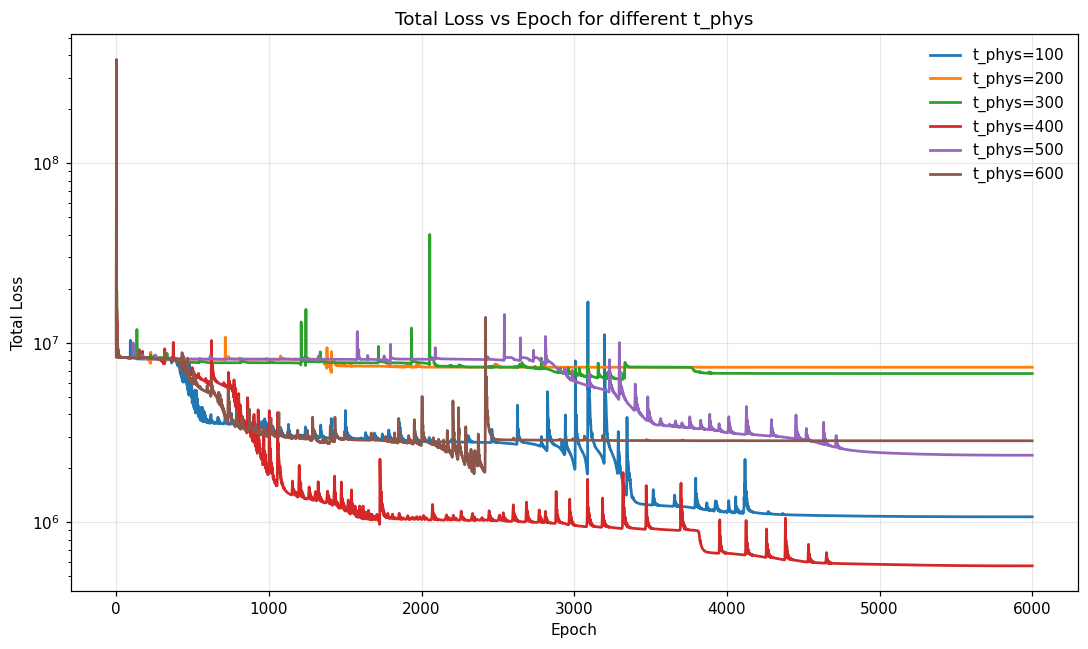

In [72]:
import math
import os
from collections import OrderedDict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float32)
plt.rcParams["figure.dpi"] = 110


Norm_T = 3e-4
t1_phys, t2_phys, t3_phys, V_max = 6e-6, 26e-6, 32e-6, 24
t1 = t1_phys / Norm_T
t2 = t2_phys / Norm_T
t3 = t3_phys / Norm_T


def f_ext(t, F_gain):
    f_val = (
        V_max / t1 * (1 - (t > t1).float())
        - V_max / (t3 - t2) * ((t > t2).float() - (t > t3).float())
    )
    return F_gain * (f_val * Norm_T)


def load_experiment_csv(csv_path, t_end=1.0, n_full=300, data_range=(0.0, 1.0), n_data=600):
    df = pd.read_csv(csv_path)
    vals = df.iloc[0, :n_full].astype(np.float32).to_numpy()
    y_full = torch.from_numpy(vals).view(-1, 1).to(DEVICE)
    t_full = torch.linspace(0.0, t_end, n_full, device=DEVICE).view(-1, 1)
    s = int(data_range[0] / t_end * (n_full - 1))
    e = int(data_range[1] / t_end * (n_full - 1))
    idx = torch.linspace(s, e, n_data, dtype=torch.long, device=DEVICE)
    return t_full, y_full, t_full[idx], y_full[idx]


class PIDoN(nn.Module):
    def __init__(self, latent: int = 32):
        super().__init__()

        self.branch = nn.Sequential(OrderedDict([
            ("b1", nn.Linear(4, 256)), ("ba1", nn.GELU()),
            ("b2", nn.Linear(256, 256)), ("ba2", nn.GELU()),
            ("b3", nn.Linear(256, 256)), ("ba3", nn.GELU()),
            ("b4", nn.Linear(256, 256)), ("ba4", nn.GELU()),
            ("b5", nn.Linear(256, 256)), ("ba5", nn.GELU()),
            ("bout", nn.Linear(256, latent))
        ]))

        self.trunk = nn.Sequential(OrderedDict([
            ("t1", nn.Linear(1, 256)), ("ta1", nn.GELU()),
            ("t2", nn.Linear(256, 256)), ("ta2", nn.GELU()),
            ("t3", nn.Linear(256, 256)), ("ta3", nn.GELU()),
            ("t4", nn.Linear(256, 256)), ("ta4", nn.GELU()),
            ("t5", nn.Linear(256, 256)), ("ta5", nn.GELU()),
            ("tout", nn.Linear(256, latent))
        ]))

        self.g_net = nn.Sequential(OrderedDict([
            ("g1", nn.Linear(1, 256)), ("ga1", nn.GELU()),
            ("g2", nn.Linear(256, 256)), ("ga2", nn.GELU()),
            ("g3", nn.Linear(256, 256)), ("ga3", nn.GELU()),
            ("g4", nn.Linear(256, 256)), ("ga4", nn.GELU()),
            ("g5", nn.Linear(256, 256)), ("ga5", nn.GELU()),
            ("gout", nn.Linear(256, latent))
        ]))

        self.bias = nn.Parameter(torch.zeros(1, 1, dtype=torch.get_default_dtype()))

    def forward(self, t: torch.Tensor, params: torch.Tensor) -> torch.Tensor:
        B = self.branch(params)
        T = self.trunk(t)
        G = torch.sigmoid(self.g_net(t))
        return torch.sum(B * T * G, dim=1, keepdim=True) + self.bias


def bound_osc(raw, lo, hi, step, cur_lr, lr_init, epochs_total, amp0, cycles_total, phase=0.0, amp_power=2.0):
    amp = amp0 * (max(cur_lr / lr_init, 0.0) ** amp_power)
    omega = 2.0 * math.pi * cycles_total / float(epochs_total)
    sin_term = torch.sin(torch.tensor(omega * step + phase, device=DEVICE, dtype=raw.dtype))
    raw_osc = raw + amp * sin_term
    return lo + (hi - lo) * torch.sigmoid(raw_osc)


csv_path = r"D:\Code review\Parameter identification\EG 65\3. EG65_24V.csv"

R_MIN, R_MAX = 0.5, 2.0
L_MIN, L_MAX = 150, 200
C_MIN, C_MAX = 1, 2
F_MIN, F_MAX = 6900, 8000

DATA_WEIGHT = 1e6
PHYS_WEIGHT = 1e-9
IC_WEIGHT = 1e1

LR_INIT = 1e-3
EPOCHS = 6000
PRINT_EVERY = 2000

OSC_L = dict(amp0=0.80, cycles_total=25.0, phase=0.0, amp_power=2.5)
OSC_R = dict(amp0=0.80, cycles_total=25.0, phase=1.2, amp_power=2.5)
OSC_C = dict(amp0=0.80, cycles_total=25.0, phase=2.4, amp_power=2.5)
OSC_F = dict(amp0=0.80, cycles_total=25.0, phase=3.6, amp_power=2.5)

t_phys_list = [100, 200, 300, 400, 500, 600]
out_dir = os.path.join(os.getcwd(), "loss_records_t_phys")
os.makedirs(out_dir, exist_ok=True)

loss_curves = {}

t_full, y_full, x_data, y_data = load_experiment_csv(csv_path)

for n_tphys in t_phys_list:
    model = PIDoN(latent=32).to(DEVICE)

    L_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
    R_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
    C_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
    F_raw = nn.Parameter(torch.zeros(1, device=DEVICE))

    optim = torch.optim.Adam(list(model.parameters()) + [L_raw, R_raw, C_raw, F_raw], lr=LR_INIT)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=EPOCHS, eta_min=LR_INIT * 5e-4)

    t_phys = torch.linspace(0, 1, n_tphys, device=DEVICE).view(-1, 1).requires_grad_(True)
    t_ic = torch.tensor([[0.0]], device=DEVICE, requires_grad=True)

    hist = {
        "epoch": [],
        "total_loss": [],
        "loss_data": [],
        "loss_phys": [],
        "loss_ic": [],
        "lr": [],
        "L": [],
        "R": [],
        "C": [],
        "F": [],
        "n_tphys": [],
    }

    for step in range(1, EPOCHS + 1):
        optim.zero_grad()
        cur_lr = float(optim.param_groups[0]["lr"])

        L_hat = bound_osc(L_raw, L_MIN, L_MAX, step, cur_lr, LR_INIT, EPOCHS, **OSC_L)
        R_hat = bound_osc(R_raw, R_MIN, R_MAX, step, cur_lr, LR_INIT, EPOCHS, **OSC_R)
        C_hat = bound_osc(C_raw, C_MIN, C_MAX, step, cur_lr, LR_INIT, EPOCHS, **OSC_C)
        F_hat = bound_osc(F_raw, F_MIN, F_MAX, step, cur_lr, LR_INIT, EPOCHS, **OSC_F)

        p_vec = torch.stack([L_hat, R_hat, C_hat, F_hat], dim=0).view(1, 4)

        y_pred_data = model(x_data, p_vec.repeat(x_data.size(0), 1))
        loss_data = F.mse_loss(y_pred_data, y_data)

        y_phys = model(t_phys, p_vec.repeat(t_phys.size(0), 1))
        dy = torch.autograd.grad(y_phys, t_phys, torch.ones_like(y_phys), create_graph=True, retain_graph=True)[0]
        d2y = torch.autograd.grad(dy, t_phys, torch.ones_like(dy), create_graph=True, retain_graph=True)[0]

        s_q = 1000.0
        res = (L_hat * d2y + R_hat * dy + (1.0 / C_hat) * y_phys) - (f_ext(t_phys, F_hat) * 1e-6) / s_q
        loss_phys = res.pow(2).mean()

        y0 = model(t_ic, p_vec)
        dy0 = torch.autograd.grad(y0, t_ic, torch.ones_like(y0), create_graph=True, retain_graph=True)[0]
        loss_ic = (y0.pow(2) + dy0.pow(2)).mean()

        total_loss = DATA_WEIGHT * loss_data + PHYS_WEIGHT * loss_phys + IC_WEIGHT * loss_ic
        total_loss.backward()
        optim.step()
        scheduler.step()

        hist["epoch"].append(step)
        hist["total_loss"].append(float(total_loss.detach().cpu()))
        hist["loss_data"].append(float(loss_data.detach().cpu()))
        hist["loss_phys"].append(float(loss_phys.detach().cpu()))
        hist["loss_ic"].append(float(loss_ic.detach().cpu()))
        hist["lr"].append(float(optim.param_groups[0]["lr"]))
        hist["L"].append(float(L_hat.detach().cpu()))
        hist["R"].append(float(R_hat.detach().cpu()))
        hist["C"].append(float(C_hat.detach().cpu()))
        hist["F"].append(float(F_hat.detach().cpu()))
        hist["n_tphys"].append(int(n_tphys))

        if step % PRINT_EVERY == 0:
            print(
                f"t_phys={n_tphys} | {step:>6} | lr {optim.param_groups[0]['lr']:.2e} | "
                f"total {total_loss.item():.3e} | data {loss_data.item():.3e} | "
                f"phys {loss_phys.item():.3e} | ic {loss_ic.item():.3e}"
            )

    df_hist = pd.DataFrame(hist)
    out_csv = os.path.join(out_dir, f"t_phys_{n_tphys}_loss.csv")
    df_hist.to_csv(out_csv, index=False)
    print(f"saved: {out_csv}")

    loss_curves[n_tphys] = (df_hist["epoch"].to_numpy(), df_hist["total_loss"].to_numpy())


plt.figure(figsize=(10, 6))
for n_tphys in t_phys_list:
    ep, tl = loss_curves[n_tphys]
    plt.plot(ep, tl, lw=1.8, label=f"t_phys={n_tphys}")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.yscale("log")
plt.title("Total Loss vs Epoch for different t_phys")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


LR_INIT=5.0e-03 |   2000 | lr 3.75e-03 | total 8.278e+06 | data 8.278e+00 | phys 2.994e-03 | ic 1.288e-05
LR_INIT=5.0e-03 |   4000 | lr 1.25e-03 | total 8.278e+06 | data 8.278e+00 | phys 6.983e-05 | ic 8.577e-07
LR_INIT=5.0e-03 |   6000 | lr 2.50e-06 | total 8.278e+06 | data 8.278e+00 | phys 2.891e-03 | ic 7.838e-07
saved: d:\Code review\2025-Rheological Properties-PINN\loss_records_lr_init\lr_init_5e-03_loss.csv
LR_INIT=1.0e-03 |   2000 | lr 7.50e-04 | total 5.524e+06 | data 5.509e+00 | phys 3.858e+12 | ic 1.094e+03
LR_INIT=1.0e-03 |   4000 | lr 2.50e-04 | total 3.054e+06 | data 3.026e+00 | phys 1.657e+13 | ic 1.137e+03
LR_INIT=1.0e-03 |   6000 | lr 5.00e-07 | total 2.166e+06 | data 2.127e+00 | phys 2.964e+13 | ic 9.316e+02
saved: d:\Code review\2025-Rheological Properties-PINN\loss_records_lr_init\lr_init_1e-03_loss.csv
LR_INIT=5.0e-04 |   2000 | lr 3.75e-04 | total 1.399e+06 | data 1.378e+00 | phys 1.787e+13 | ic 3.135e+02
LR_INIT=5.0e-04 |   4000 | lr 1.25e-04 | total 8.958e+05 | d

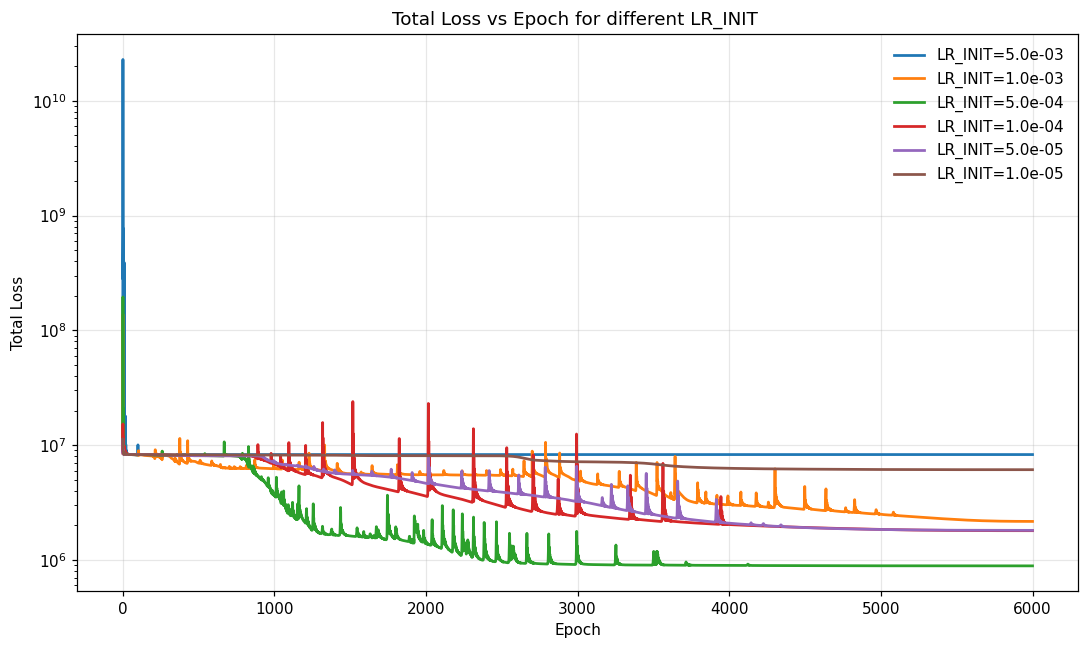

In [73]:
import math
import os
from collections import OrderedDict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float32)
plt.rcParams["figure.dpi"] = 110


Norm_T = 3e-4
t1_phys, t2_phys, t3_phys, V_max = 6e-6, 26e-6, 32e-6, 24
t1 = t1_phys / Norm_T
t2 = t2_phys / Norm_T
t3 = t3_phys / Norm_T


def f_ext(t, F_gain):
    f_val = (
        V_max / t1 * (1 - (t > t1).float())
        - V_max / (t3 - t2) * ((t > t2).float() - (t > t3).float())
    )
    return F_gain * (f_val * Norm_T)


def load_experiment_csv(csv_path, t_end=1.0, n_full=300, data_range=(0.0, 1.0), n_data=600):
    df = pd.read_csv(csv_path)
    vals = df.iloc[0, :n_full].astype(np.float32).to_numpy()
    y_full = torch.from_numpy(vals).view(-1, 1).to(DEVICE)
    t_full = torch.linspace(0.0, t_end, n_full, device=DEVICE).view(-1, 1)
    s = int(data_range[0] / t_end * (n_full - 1))
    e = int(data_range[1] / t_end * (n_full - 1))
    idx = torch.linspace(s, e, n_data, dtype=torch.long, device=DEVICE)
    return t_full, y_full, t_full[idx], y_full[idx]


class PIDoN(nn.Module):
    def __init__(self, latent: int = 32):
        super().__init__()

        self.branch = nn.Sequential(OrderedDict([
            ("b1", nn.Linear(4, 256)), ("ba1", nn.GELU()),
            ("b2", nn.Linear(256, 256)), ("ba2", nn.GELU()),
            ("b3", nn.Linear(256, 256)), ("ba3", nn.GELU()),
            ("b4", nn.Linear(256, 256)), ("ba4", nn.GELU()),
            ("b5", nn.Linear(256, 256)), ("ba5", nn.GELU()),
            ("bout", nn.Linear(256, latent))
        ]))

        self.trunk = nn.Sequential(OrderedDict([
            ("t1", nn.Linear(1, 256)), ("ta1", nn.GELU()),
            ("t2", nn.Linear(256, 256)), ("ta2", nn.GELU()),
            ("t3", nn.Linear(256, 256)), ("ta3", nn.GELU()),
            ("t4", nn.Linear(256, 256)), ("ta4", nn.GELU()),
            ("t5", nn.Linear(256, 256)), ("ta5", nn.GELU()),
            ("tout", nn.Linear(256, latent))
        ]))

        self.g_net = nn.Sequential(OrderedDict([
            ("g1", nn.Linear(1, 256)), ("ga1", nn.GELU()),
            ("g2", nn.Linear(256, 256)), ("ga2", nn.GELU()),
            ("g3", nn.Linear(256, 256)), ("ga3", nn.GELU()),
            ("g4", nn.Linear(256, 256)), ("ga4", nn.GELU()),
            ("g5", nn.Linear(256, 256)), ("ga5", nn.GELU()),
            ("gout", nn.Linear(256, latent))
        ]))

        self.bias = nn.Parameter(torch.zeros(1, 1, dtype=torch.get_default_dtype()))

    def forward(self, t: torch.Tensor, params: torch.Tensor) -> torch.Tensor:
        B = self.branch(params)
        T = self.trunk(t)
        G = torch.sigmoid(self.g_net(t))
        return torch.sum(B * T * G, dim=1, keepdim=True) + self.bias


def bound_osc(raw, lo, hi, step, cur_lr, lr_init, epochs_total, amp0, cycles_total, phase=0.0, amp_power=2.0):
    amp = amp0 * (max(cur_lr / lr_init, 0.0) ** amp_power)
    omega = 2.0 * math.pi * cycles_total / float(epochs_total)
    sin_term = torch.sin(torch.tensor(omega * step + phase, device=DEVICE, dtype=raw.dtype))
    raw_osc = raw + amp * sin_term
    return lo + (hi - lo) * torch.sigmoid(raw_osc)


csv_path = r"D:\Code review\Parameter identification\EG 65\3. EG65_24V.csv"

R_MIN, R_MAX = 0.5, 2.0
L_MIN, L_MAX = 150, 200
C_MIN, C_MAX = 1, 2
F_MIN, F_MAX = 6900, 8000

DATA_WEIGHT = 1e6
PHYS_WEIGHT = 1e-9
IC_WEIGHT = 1e1

EPOCHS = 6000
PRINT_EVERY = 2000

OSC_L = dict(amp0=0.80, cycles_total=25.0, phase=0.0, amp_power=2.5)
OSC_R = dict(amp0=0.80, cycles_total=25.0, phase=1.2, amp_power=2.5)
OSC_C = dict(amp0=0.80, cycles_total=25.0, phase=2.4, amp_power=2.5)
OSC_F = dict(amp0=0.80, cycles_total=25.0, phase=3.6, amp_power=2.5)

LR_INIT_list = [5e-3, 1e-3, 5e-4, 1e-4, 5e-5, 1e-5]

out_dir = os.path.join(os.getcwd(), "loss_records_lr_init")
os.makedirs(out_dir, exist_ok=True)

loss_curves = {}

t_full, y_full, x_data, y_data = load_experiment_csv(csv_path)

t_phys = torch.linspace(0, 1, 100, device=DEVICE).view(-1, 1).requires_grad_(True)
t_ic = torch.tensor([[0.0]], device=DEVICE, requires_grad=True)

for LR_INIT in LR_INIT_list:
    model = PIDoN(latent=32).to(DEVICE)

    L_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
    R_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
    C_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
    F_raw = nn.Parameter(torch.zeros(1, device=DEVICE))

    optim = torch.optim.Adam(list(model.parameters()) + [L_raw, R_raw, C_raw, F_raw], lr=LR_INIT)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=EPOCHS, eta_min=LR_INIT * 5e-4)

    hist = {
        "epoch": [],
        "total_loss": [],
        "loss_data": [],
        "loss_phys": [],
        "loss_ic": [],
        "lr": [],
        "L": [],
        "R": [],
        "C": [],
        "F": [],
        "LR_INIT": [],
    }

    for step in range(1, EPOCHS + 1):
        optim.zero_grad()
        cur_lr = float(optim.param_groups[0]["lr"])

        L_hat = bound_osc(L_raw, L_MIN, L_MAX, step, cur_lr, LR_INIT, EPOCHS, **OSC_L)
        R_hat = bound_osc(R_raw, R_MIN, R_MAX, step, cur_lr, LR_INIT, EPOCHS, **OSC_R)
        C_hat = bound_osc(C_raw, C_MIN, C_MAX, step, cur_lr, LR_INIT, EPOCHS, **OSC_C)
        F_hat = bound_osc(F_raw, F_MIN, F_MAX, step, cur_lr, LR_INIT, EPOCHS, **OSC_F)

        p_vec = torch.stack([L_hat, R_hat, C_hat, F_hat], dim=0).view(1, 4)

        y_pred_data = model(x_data, p_vec.repeat(x_data.size(0), 1))
        loss_data = F.mse_loss(y_pred_data, y_data)

        y_phys = model(t_phys, p_vec.repeat(t_phys.size(0), 1))
        dy = torch.autograd.grad(y_phys, t_phys, torch.ones_like(y_phys), create_graph=True, retain_graph=True)[0]
        d2y = torch.autograd.grad(dy, t_phys, torch.ones_like(dy), create_graph=True, retain_graph=True)[0]

        s_q = 1000.0
        res = (L_hat * d2y + R_hat * dy + (1.0 / C_hat) * y_phys) - (f_ext(t_phys, F_hat) * 1e-6) / s_q
        loss_phys = res.pow(2).mean()

        y0 = model(t_ic, p_vec)
        dy0 = torch.autograd.grad(y0, t_ic, torch.ones_like(y0), create_graph=True, retain_graph=True)[0]
        loss_ic = (y0.pow(2) + dy0.pow(2)).mean()

        total_loss = DATA_WEIGHT * loss_data + PHYS_WEIGHT * loss_phys + IC_WEIGHT * loss_ic
        total_loss.backward()
        optim.step()
        scheduler.step()

        hist["epoch"].append(step)
        hist["total_loss"].append(float(total_loss.detach().cpu()))
        hist["loss_data"].append(float(loss_data.detach().cpu()))
        hist["loss_phys"].append(float(loss_phys.detach().cpu()))
        hist["loss_ic"].append(float(loss_ic.detach().cpu()))
        hist["lr"].append(float(optim.param_groups[0]["lr"]))
        hist["L"].append(float(L_hat.detach().cpu()))
        hist["R"].append(float(R_hat.detach().cpu()))
        hist["C"].append(float(C_hat.detach().cpu()))
        hist["F"].append(float(F_hat.detach().cpu()))
        hist["LR_INIT"].append(float(LR_INIT))

        if step % PRINT_EVERY == 0:
            print(
                f"LR_INIT={LR_INIT:.1e} | {step:>6} | lr {optim.param_groups[0]['lr']:.2e} | "
                f"total {total_loss.item():.3e} | data {loss_data.item():.3e} | "
                f"phys {loss_phys.item():.3e} | ic {loss_ic.item():.3e}"
            )

    df_hist = pd.DataFrame(hist)
    lr_tag = f"{LR_INIT:.0e}".replace("+", "")
    out_csv = os.path.join(out_dir, f"lr_init_{lr_tag}_loss.csv")
    df_hist.to_csv(out_csv, index=False)
    print(f"saved: {out_csv}")

    loss_curves[LR_INIT] = (df_hist["epoch"].to_numpy(), df_hist["total_loss"].to_numpy())


plt.figure(figsize=(10, 6))
for LR_INIT in LR_INIT_list:
    ep, tl = loss_curves[LR_INIT]
    plt.plot(ep, tl, lw=1.8, label=f"LR_INIT={LR_INIT:.1e}")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.yscale("log")
plt.title("Total Loss vs Epoch for different LR_INIT ")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


  2000 | lr 7.50e-04 | data 1.09e+00 | phys 5.26e+13 | ic 8.97e+02 | L 1.619873e+02 R 1.223185e+00 C 1.407061e+00 F 7.387773e+03 | grad 1.61e+07


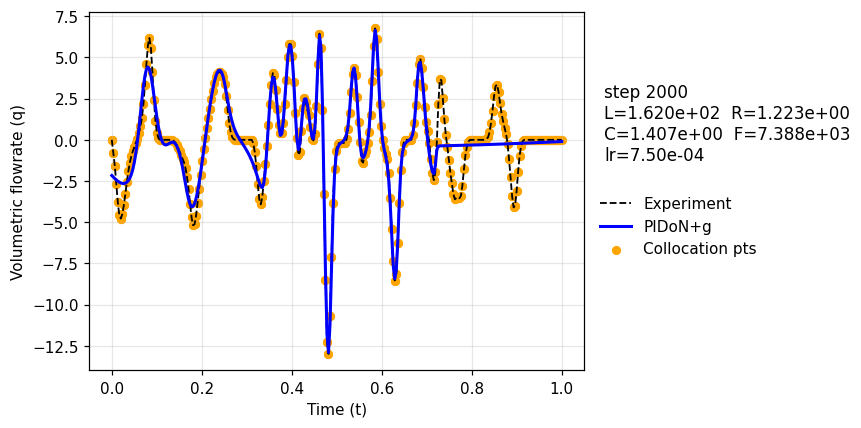

  4000 | lr 2.50e-04 | data 3.98e-01 | phys 3.44e+13 | ic 2.94e+00 | L 1.549073e+02 R 1.235751e+00 C 1.503091e+00 F 7.453887e+03 | grad 6.51e+06


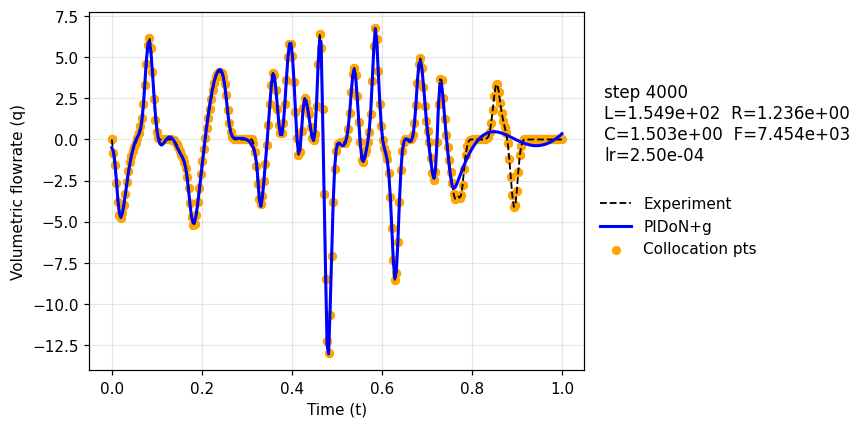

  6000 | lr 5.00e-07 | data 3.27e-01 | phys 2.83e+13 | ic 6.41e-01 | L 1.545356e+02 R 1.243126e+00 C 1.501193e+00 F 7.446980e+03 | grad 4.55e+04


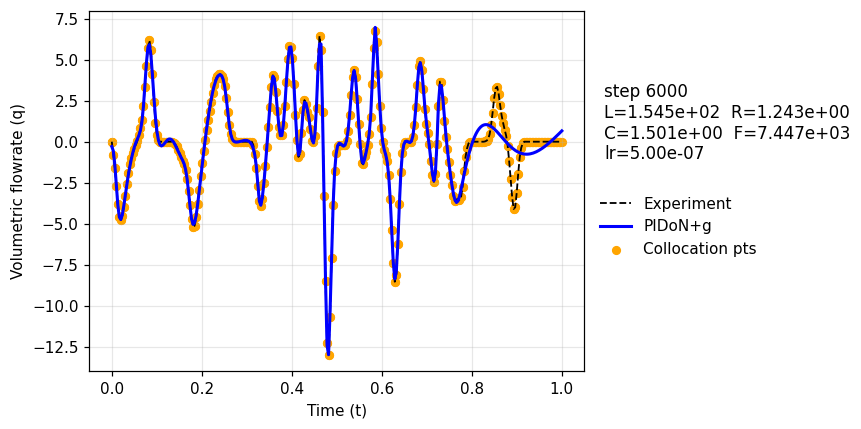

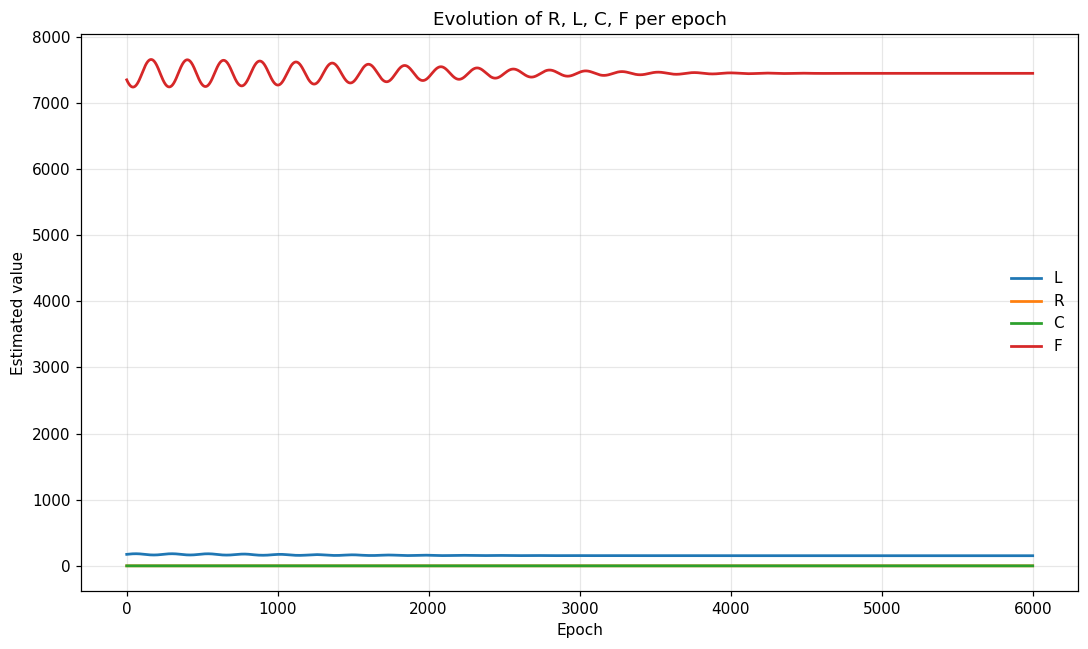

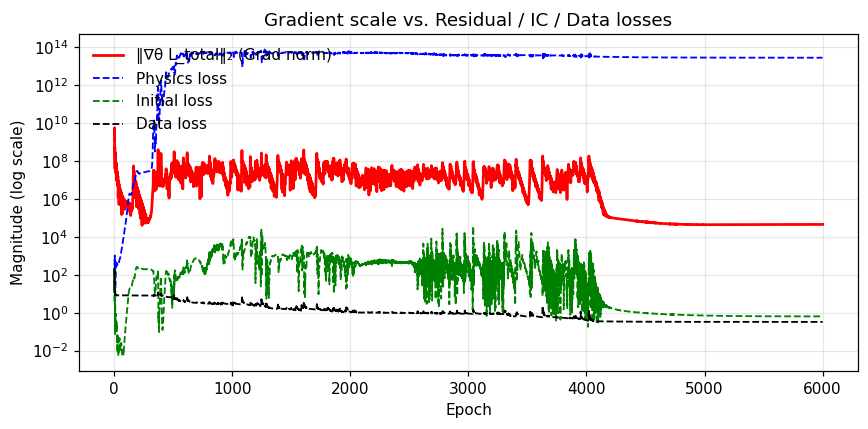

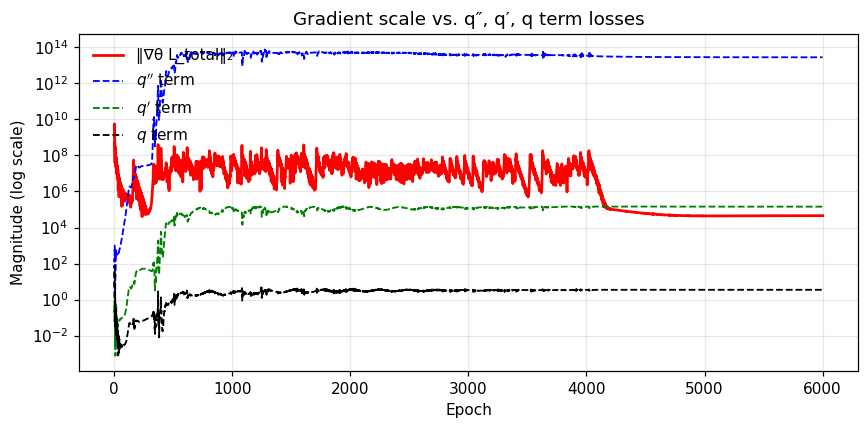

In [74]:
import math, pandas as pd
from collections import OrderedDict
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os, sys, re

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float32)
plt.rcParams["figure.dpi"] = 110

Norm_T = 3e-4
t1_phys, t2_phys, t3_phys, V_max = 6e-6, 26e-6, 32e-6, 24
t1 = t1_phys / Norm_T
t2 = t2_phys / Norm_T
t3 = t3_phys / Norm_T

def f_ext(t, F_gain):
    f_val = (
        V_max/t1 * (1 - (t > (t1)).float())
        - V_max/(t3 - t2) * ((t > (t2)).float() - (t > (t3)).float())
    )
    return F_gain * (f_val * Norm_T)

def load_experiment_csv(csv_path, t_end=1.0, n_full=300, data_range=(0.0, 1.0), n_data=600):
    df = pd.read_csv(csv_path)
    vals = df.iloc[0, :n_full].astype(np.float32).to_numpy()
    y_full = torch.from_numpy(vals).view(-1, 1).to(DEVICE)
    t_full = torch.linspace(0.0, t_end, n_full, device=DEVICE).view(-1, 1)
    s, e = (int(data_range[0]/t_end*(n_full-1)), int(data_range[1]/t_end*(n_full-1)))
    idx = torch.linspace(s, e, n_data, dtype=torch.long, device=DEVICE)
    return t_full, y_full, t_full[idx], y_full[idx]

csv_path = r"D:\Code review\Parameter identification\EG 65\3. EG65_24V.csv"
t_full, y_full, x_data, y_data = load_experiment_csv(csv_path)

class PIDoN(nn.Module):
    def __init__(self, latent: int = 32):
        super().__init__()
        self.branch = nn.Sequential(OrderedDict([
            ("b1", nn.Linear(4,   256)), ("a1", nn.GELU()),
            ("b2", nn.Linear(256, 256)), ("a2", nn.GELU()),
            ("b3", nn.Linear(256, 256)), ("a3", nn.GELU()),
            ("b4", nn.Linear(256, 256)), ("a4", nn.GELU()),
            ("b5", nn.Linear(256, 256)), ("a5", nn.GELU()),
            ("bout", nn.Linear(256, latent))
        ]))
        self.trunk = nn.Sequential(OrderedDict([
            ("t1", nn.Linear(1,   256)), ("a1", nn.GELU()),
            ("t2", nn.Linear(256, 256)), ("a2", nn.GELU()),
            ("t3", nn.Linear(256, 256)), ("a3", nn.GELU()),
            ("t4", nn.Linear(256, 256)), ("a4", nn.GELU()),
            ("t5", nn.Linear(256, 256)), ("a5", nn.GELU()),
            ("tout", nn.Linear(256, latent))
        ]))
        self.g_net = nn.Sequential(OrderedDict([
            ("g1", nn.Linear(1,   256)), ("a1", nn.GELU()),
            ("g2", nn.Linear(256, 256)), ("a2", nn.GELU()),
            ("g3", nn.Linear(256, 256)), ("a3", nn.GELU()),
            ("g4", nn.Linear(256, 256)), ("a4", nn.GELU()),
            ("g5", nn.Linear(256, 256)), ("a5", nn.GELU()),
            ("gout", nn.Linear(256, latent))
        ]))
        self.bias = nn.Parameter(torch.zeros(1, 1, dtype=torch.get_default_dtype()))

    def forward(self, t: torch.Tensor, params: torch.Tensor) -> torch.Tensor:
        B = self.branch(params)
        T = self.trunk(t)
        G = torch.sigmoid(self.g_net(t))
        return torch.sum(B * T * G, dim=1, keepdim=True) + self.bias

model = PIDoN(latent=32).to(DEVICE)

R_MIN, R_MAX = 0.5, 2.0
L_MIN, L_MAX = 150, 200
C_MIN, C_MAX = 1, 2
F_MIN, F_MAX = 6900, 8000

L_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
R_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
C_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
F_raw = nn.Parameter(torch.zeros(1, device=DEVICE))

def bound_osc(raw, lo, hi, step: int, cur_lr: float, lr_init: float, amp0: float, cycles_total: float, phase: float = 0.0, amp_power: float = 2.0):
    amp = amp0 * (max(cur_lr / lr_init, 0.0) ** amp_power)
    omega = 2.0 * math.pi * cycles_total / float(EPOCHS)
    sin_term = torch.sin(torch.tensor(omega * step + phase, device=DEVICE, dtype=raw.dtype))
    raw_osc = raw + amp * sin_term
    return lo + (hi - lo) * torch.sigmoid(raw_osc)

DATA_WEIGHT = 1e6
PHYS_WEIGHT = 1e-9
IC_WEIGHT = 1e1

t_phys = torch.linspace(0, 1, 200, device=DEVICE).view(-1,1).requires_grad_(True)
t_ic = torch.tensor([[0.0]], device=DEVICE, requires_grad=True)

LR_INIT = 1e-3
optim = torch.optim.Adam(list(model.parameters()) + [L_raw, R_raw, C_raw, F_raw], lr=LR_INIT)

EPOCHS = 6000
PLOT_EVERY = 2000
PRINT_EVERY = 2000
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=EPOCHS, eta_min=LR_INIT*5e-4)

OSC_L = dict(amp0=0.80, cycles_total=25.0, phase=0.0, amp_power=2.5)
OSC_R = dict(amp0=0.80, cycles_total=25.0, phase=1.2, amp_power=2.5)
OSC_C = dict(amp0=0.80, cycles_total=25.0, phase=2.4, amp_power=2.5)
OSC_F = dict(amp0=0.80, cycles_total=25.0, phase=3.6, amp_power=2.5)

param_hist = {"epoch": [], "L": [], "R": [], "C": [], "F": []}
lr_hist = {"epoch": [], "lr": []}

loss_hist = {"epoch": [], "data": [], "phys": [], "ic": [], "total": [], "q_ddot": [], "q_dot": [], "q": []}
grad_hist = {"epoch": [], "grad_norm": []}

s_q = 1000.0

for step in range(1, EPOCHS + 1):
    optim.zero_grad()
    cur_lr = float(optim.param_groups[0]["lr"])

    L_hat = bound_osc(L_raw, L_MIN, L_MAX, step, cur_lr, LR_INIT, **OSC_L)
    R_hat = bound_osc(R_raw, R_MIN, R_MAX, step, cur_lr, LR_INIT, **OSC_R)
    C_hat = bound_osc(C_raw, C_MIN, C_MAX, step, cur_lr, LR_INIT, **OSC_C)
    F_hat = bound_osc(F_raw, F_MIN, F_MAX, step, cur_lr, LR_INIT, **OSC_F)

    p_vec = torch.stack([L_hat, R_hat, C_hat, F_hat], dim=0).view(1, 4)

    y_pred_data = model(x_data, p_vec.repeat(x_data.size(0), 1))
    loss_data = F.mse_loss(y_pred_data, y_data)

    y_phys = model(t_phys, p_vec.repeat(t_phys.size(0), 1))
    dy = torch.autograd.grad(y_phys, t_phys, torch.ones_like(y_phys), create_graph=True, retain_graph=True)[0]
    d2y = torch.autograd.grad(dy, t_phys, torch.ones_like(dy), create_graph=True, retain_graph=True)[0]

    term_qddot = L_hat * d2y
    term_qdot = R_hat * dy
    term_q = (1.0 / C_hat) * y_phys
    rhs = (f_ext(t_phys, F_hat) * 1e-6) / s_q

    res = (term_qddot + term_qdot + term_q) - rhs
    loss_phys = res.pow(2).mean()

    loss_qddot = term_qddot.pow(2).mean()
    loss_qdot = term_qdot.pow(2).mean()
    loss_q = term_q.pow(2).mean()

    y0 = model(t_ic, p_vec)
    dy0 = torch.autograd.grad(y0, t_ic, torch.ones_like(y0), create_graph=True, retain_graph=True)[0]
    loss_ic = (y0.pow(2) + dy0.pow(2)).mean()

    total_loss = DATA_WEIGHT * loss_data + PHYS_WEIGHT * loss_phys + IC_WEIGHT * loss_ic
    total_loss.backward()

    grad_sq = 0.0
    for p in list(model.parameters()) + [L_raw, R_raw, C_raw, F_raw]:
        if p.grad is not None:
            g = p.grad.detach()
            grad_sq += float(torch.sum(g * g).cpu())
    grad_norm = math.sqrt(grad_sq)

    optim.step()
    scheduler.step()

    param_hist["epoch"].append(step)
    param_hist["L"].append(float(L_hat.detach().cpu()))
    param_hist["R"].append(float(R_hat.detach().cpu()))
    param_hist["C"].append(float(C_hat.detach().cpu()))
    param_hist["F"].append(float(F_hat.detach().cpu()))
    lr_hist["epoch"].append(step)
    lr_hist["lr"].append(float(optim.param_groups[0]["lr"]))

    loss_hist["epoch"].append(step)
    loss_hist["data"].append(float(loss_data.detach().cpu()))
    loss_hist["phys"].append(float(loss_phys.detach().cpu()))
    loss_hist["ic"].append(float(loss_ic.detach().cpu()))
    loss_hist["total"].append(float(total_loss.detach().cpu()))
    loss_hist["q_ddot"].append(float(loss_qddot.detach().cpu()))
    loss_hist["q_dot"].append(float(loss_qdot.detach().cpu()))
    loss_hist["q"].append(float(loss_q.detach().cpu()))

    grad_hist["epoch"].append(step)
    grad_hist["grad_norm"].append(float(grad_norm))

    if step % PRINT_EVERY == 0:
        cur_lr2 = optim.param_groups[0]["lr"]
        print(f"{step:>6} | lr {cur_lr2:.2e} | data {loss_data.item():.2e} | phys {loss_phys.item():.2e} | ic {loss_ic.item():.2e} | L {L_hat.item():.6e} R {R_hat.item():.6e} C {C_hat.item():.6e} F {F_hat.item():.6e} | grad {grad_norm:.2e}")

    if step % PLOT_EVERY == 0:
        with torch.no_grad():
            y_hat_mid = model(t_full, p_vec.repeat(t_full.size(0), 1)).cpu()
        plt.figure(figsize=(8, 4))
        plt.plot(t_full.cpu(), y_full.cpu(), 'k--', lw=1.2, label='Experiment')
        plt.plot(t_full.cpu(), y_hat_mid, 'b', lw=2.0, label='PIDoN+g')
        plt.scatter(x_data.cpu(), y_data.cpu(), c='orange', s=25, label='Collocation pts')
        plt.xlabel("Time (t)")
        plt.ylabel("Volumetric flowrate (q)")
        plt.grid(alpha=0.3)
        plt.legend(frameon=False, loc=(1.02, 0.30))
        plt.text(1.04, 0.80,
                 f"step {step}\n"
                 f"L={L_hat.item():.3e}  R={R_hat.item():.3e}\n"
                 f"C={C_hat.item():.3e}  F={F_hat.item():.3e}\n"
                 f"lr={optim.param_groups[0]['lr']:.2e}",
                 transform=plt.gca().transAxes, va='top', fontsize=11)
        plt.tight_layout()
        plt.show()

loss_df = pd.DataFrame(loss_hist)
grad_df = pd.DataFrame(grad_hist)

loss_df.to_csv("loss_df.csv", index=False)
grad_df.to_csv("grad_df.csv", index=False)

plt.figure(figsize=(10, 6))
plt.plot(param_hist["epoch"], param_hist["L"], label="L", lw=1.8)
plt.plot(param_hist["epoch"], param_hist["R"], label="R", lw=1.8)
plt.plot(param_hist["epoch"], param_hist["C"], label="C", lw=1.8)
plt.plot(param_hist["epoch"], param_hist["F"], label="F", lw=1.8)
plt.xlabel("Epoch")
plt.ylabel("Estimated value")
plt.title("Evolution of R, L, C, F per epoch")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

grad_resid_df = pd.DataFrame({
    "Epoch": loss_df["epoch"],
    "Grad_norm": grad_df["grad_norm"],
    "Physics_loss": loss_df["phys"],
    "IC_loss": loss_df["ic"],
    "Data_loss": loss_df["data"]
})
grad_resid_df.to_csv("plot2_grad_vs_residual_ic_data.csv", index=False)

plt.figure(figsize=(8,4))
plt.plot(grad_df["epoch"], grad_df["grad_norm"], 'r-', lw=1.8, label="‖∇θ L_total‖₂ (Grad norm)")
plt.plot(loss_df["epoch"], loss_df["phys"], 'b--', lw=1.2, label="Physics loss")
plt.plot(loss_df["epoch"], loss_df["ic"], 'g--', lw=1.2, label="Initial loss")
plt.plot(loss_df["epoch"], loss_df["data"], 'k--', lw=1.2, label="Data loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Magnitude (log scale)")
plt.title("Gradient scale vs. Residual / IC / Data losses")
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

grad_qterm_df = pd.DataFrame({
    "Epoch": loss_df["epoch"],
    "Grad_norm": grad_df["grad_norm"],
    "q_ddot_term_loss": loss_df["q_ddot"],
    "q_dot_term_loss": loss_df["q_dot"],
    "q_term_loss": loss_df["q"]
})
grad_qterm_df.to_csv("plot3_grad_vs_qterms.csv", index=False)

plt.figure(figsize=(8,4))
plt.plot(grad_df["epoch"], grad_df["grad_norm"], 'r-', lw=1.8, label="‖∇θ L_total‖₂")
plt.plot(loss_df["epoch"], loss_df["q_ddot"], 'b--', lw=1.2, label=r"$q''$ term")
plt.plot(loss_df["epoch"], loss_df["q_dot"], 'g--', lw=1.2, label=r"$q'$ term")
plt.plot(loss_df["epoch"], loss_df["q"], 'k--', lw=1.2, label=r"$q$ term")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Magnitude (log scale)")
plt.title("Gradient scale vs. q″, q′, q term losses")
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---

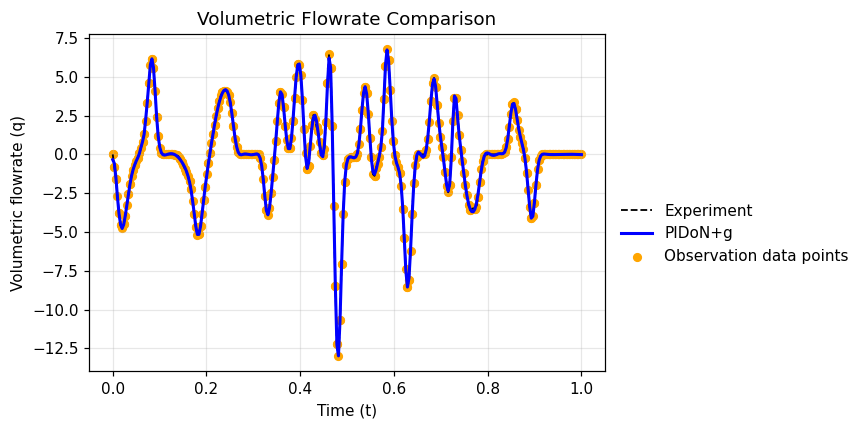

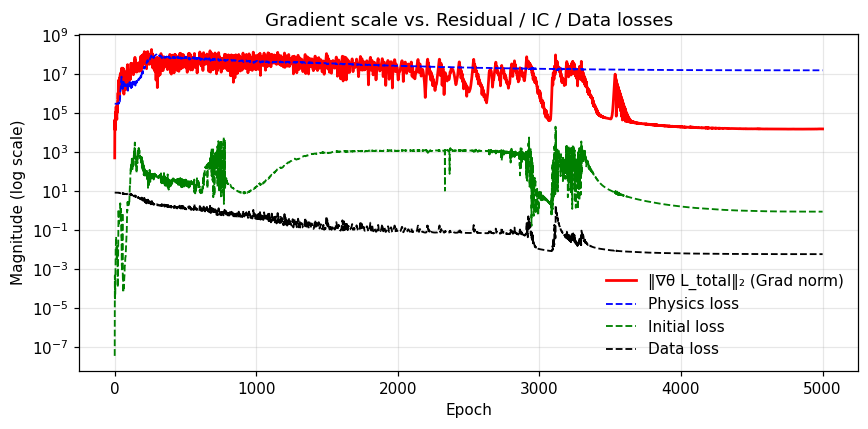

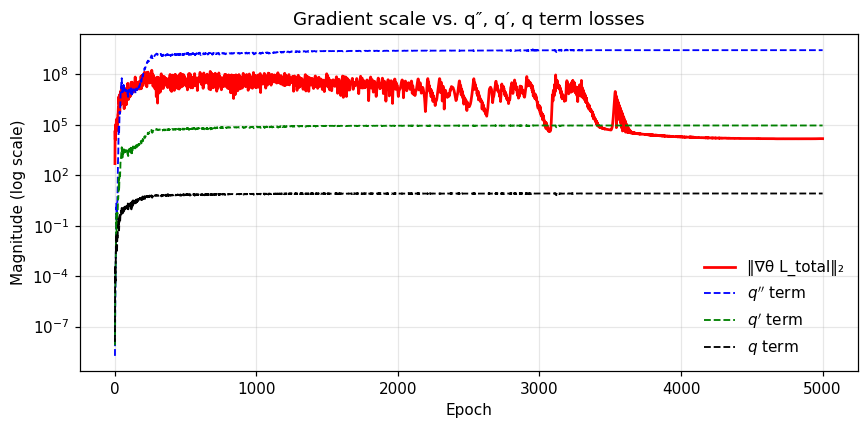

In [4]:
# ═════════════ 0. 라이브러리 · 환경 설정 ─══════════════════════════
import math, pandas as pd
from collections import OrderedDict
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os, sys, re

# ── GPU/CPU 자동 선택
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float32)
plt.rcParams["figure.dpi"] = 110

# ═════════════ 1. 외력 함수 f_ext(t,F) 정의 ─═════════════════════════
t1, t2, t3, V_max = 6e-6, 26e-6, 32e-6, 24
Norm_T = 3e-4  # 전체 구간: 0~300 μs

def f_ext(t, F_gain):
    """정규화된 시간에서 외력 펄스 함수 생성"""
    f_val = (
        V_max/t1 * (1 - (t > (t1/Norm_T)).float())
        - V_max/(t3 - t2) * ((t > (t2/Norm_T)).float() - (t > (t3/Norm_T)).float())
    )
    return f_val * F_gain * Norm_T

# ═════════════ 2. 실험 CSV 데이터 로드 함수 ─═════════════════════════
def load_experiment_csv(csv_path, t_end=1.0, n_full=300, data_range=(0.0, 1.0), n_data=500):
    """실험 CSV를 불러와 학습·검증 세트로 분할"""
    df = pd.read_csv(csv_path)
    vals = df.iloc[0, :n_full].astype(np.float32).to_numpy()
    y_full = torch.from_numpy(vals).view(-1, 1).to(DEVICE)
    t_full = torch.linspace(0.0, t_end, n_full, device=DEVICE).view(-1, 1)

    s, e = (int(data_range[0]/t_end*(n_full-1)),
            int(data_range[1]/t_end*(n_full-1)))
    idx = torch.linspace(s, e, n_data, dtype=torch.long, device=DEVICE)
    return t_full, y_full, t_full[idx], y_full[idx]

# ── 실험 CSV 경로 (실제 데이터 사용)
csv_path = r"D:\Code review\Parameter identification\EG 65\3. EG65_24V.csv"
t_full, y_full, x_data, y_data = load_experiment_csv(csv_path)

# ═════════════ 3. PIDoN 네트워크 정의 ─══════════════════════════════
class PIDoN(nn.Module):
    """Physics-Informed Deep Operator Network"""
    def __init__(self, latent: int = 32):
        super().__init__()
        def block(n_in, n_hidden, n_layer):
            layers = [("in", nn.Linear(n_in, n_hidden)), ("act_in", nn.GELU())]
            for i in range(1, n_layer):
                layers.append((f"l{i}", nn.Linear(n_hidden, n_hidden)))
                layers.append((f"a{i}", nn.GELU()))
            return nn.Sequential(OrderedDict(layers))
        self.branch = block(4, 256, 6); self.branch.add_module("bout", nn.Linear(256, latent))
        self.trunk  = block(1, 256, 6); self.trunk.add_module("tout", nn.Linear(256, latent))
        self.g_net  = block(1, 256, 6); self.g_net.add_module("gout", nn.Linear(256, latent))
        self.bias = nn.Parameter(torch.zeros(1, 1))
    def forward(self, t, params):
        B = self.branch(params); T = self.trunk(t); G = torch.sigmoid(self.g_net(t))
        return torch.sum(B * T * G, dim=1, keepdim=True) + self.bias

model = PIDoN(latent=32).to(DEVICE)

# ═════════════ 4. 파라미터 설정 및 구간 제약 ─════════════════════════
L_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
R_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
C_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
F_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
R_MIN,R_MAX,L_MIN,L_MAX,C_MIN,C_MAX,F_MIN,F_MAX = 0.1,50.0,0.03,0.5,0.008,0.5,-2.5,-2.0
def bound_param(p_raw, lo, hi): return lo + (hi - lo) * torch.sigmoid(p_raw)

# ═════════════ 5. 학습 설정 ─═════════════════════════════════════════
DATA_WEIGHT, PHYS_WEIGHT, IC_WEIGHT = 1e6, 1e-4, 1e1
t_phys = torch.linspace(0, 1, 200, device=DEVICE).view(-1,1).requires_grad_(True)
t_ic   = torch.tensor([[0.0]], device=DEVICE, requires_grad=True)
LR_INIT, EPOCHS, PLOT_EVERY, PRINT_EVERY = 1e-3, 5000, 5000, 5000
optim = torch.optim.Adam(list(model.parameters())+[L_raw,R_raw,C_raw,F_raw], lr=LR_INIT)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=EPOCHS, eta_min=LR_INIT*5e-4)

# ═════════════ 6. 기록 버퍼 초기화 ─═════════════════════════════════
param_hist, lr_hist = {"epoch":[],"L":[],"R":[],"C":[],"F":[]}, {"epoch":[],"lr":[]}
loss_hist, grad_hist = {"epoch":[],"data":[],"phys":[],"ic":[],"q":[],"q_dot":[],"q_ddot":[]}, {"epoch":[],"grad_norm":[]}

# ═════════════ 7. 학습 루프 ─════════════════════════════════════════
for step in range(1,EPOCHS+1):
    optim.zero_grad()
    # 파라미터 바운딩
    L_hat,R_hat,C_hat,F_hat = bound_param(L_raw,L_MIN,L_MAX),bound_param(R_raw,R_MIN,R_MAX),bound_param(C_raw,C_MIN,C_MAX),bound_param(F_raw,F_MIN,F_MAX)
    p_vec = torch.tensor([[L_hat.item(),R_hat.item(),C_hat.item(),F_hat.item()]], device=DEVICE)

    # (a) Data loss
    y_pred_data = model(x_data,p_vec.repeat(x_data.size(0),1))
    loss_data = F.mse_loss(y_pred_data,y_data)

    # (b) Physics residual loss
    y_phys = model(t_phys,p_vec.repeat(t_phys.size(0),1))
    dy  = torch.autograd.grad(y_phys,t_phys,torch.ones_like(y_phys),create_graph=True,retain_graph=True)[0]
    d2y = torch.autograd.grad(dy,t_phys,torch.ones_like(dy),create_graph=True,retain_graph=True)[0]
    res = L_hat*d2y + R_hat*dy + (1.0/C_hat)*y_phys - f_ext(t_phys,F_hat)
    loss_phys = res.pow(2).mean()

    # (c) Initial condition loss
    y0=model(t_ic,p_vec); dy0=torch.autograd.grad(y0,t_ic,torch.ones_like(y0),create_graph=True,retain_graph=True)[0]
    loss_ic = y0.pow(2)+dy0.pow(2)

    # (d) Total loss 및 역전파
    total_loss = DATA_WEIGHT*loss_data + PHYS_WEIGHT*loss_phys + IC_WEIGHT*loss_ic
    total_loss.backward()

    # (e) Gradient norm 계산
    total_grad_norm=0.0
    with torch.no_grad():
        for _,param in model.named_parameters():
            if param.grad is not None:
                total_grad_norm += param.grad.norm(2).item()**2
        total_grad_norm = total_grad_norm**0.5

    # (f) 최적화 step
    grad_hist["epoch"].append(step); grad_hist["grad_norm"].append(total_grad_norm)
    optim.step(); scheduler.step()

    # (g) 기록
    param_hist["epoch"].append(step)
    param_hist["L"].append(L_hat.item()); param_hist["R"].append(R_hat.item())
    param_hist["C"].append(C_hat.item()); param_hist["F"].append(F_hat.item())
    lr_hist["epoch"].append(step); lr_hist["lr"].append(float(optim.param_groups[0]["lr"]))
    loss_hist["epoch"].append(step)
    loss_hist["data"].append(loss_data.item()); loss_hist["phys"].append(loss_phys.item()); loss_hist["ic"].append(float(loss_ic.item()))
    loss_hist["q"].append(y_phys.pow(2).mean().item()); loss_hist["q_dot"].append(dy.pow(2).mean().item()); loss_hist["q_ddot"].append(d2y.pow(2).mean().item())

# ═════════════ 8. 손실 및 gradient DataFrame 저장 ─═════════════════════════
loss_df, grad_df = pd.DataFrame(loss_hist), pd.DataFrame(grad_hist)
loss_df.to_csv("loss_history.csv", index=False)
grad_df.to_csv("grad_history.csv", index=False)

# ═════════════ 9. 시각화 (3개 플롯 + CSV 저장) ─══════════════════════════════

# (1) Volumetric flowrate (q) Plot & CSV
with torch.no_grad():
    y_hat_mid = model(t_full, p_vec.repeat(t_full.size(0),1)).cpu()
vol_plot_df = pd.DataFrame({
    "Time(t)": t_full.cpu().numpy().flatten(),
    "Experiment_q": y_full.cpu().numpy().flatten(),
    "PIDoN_q": y_hat_mid.numpy().flatten()
})
vol_plot_df.to_csv("plot1_volumetric_flowrate.csv", index=False)

plt.figure(figsize=(8,4))
plt.plot(t_full.cpu(), y_full.cpu(),'k--',lw=1.2,label='Experiment')
plt.plot(t_full.cpu(), y_hat_mid,'b',lw=2.0,label='PIDoN+g')
plt.scatter(x_data.cpu(),y_data.cpu(),c='orange',s=25,label='Observation data points')
plt.xlabel("Time (t)"); plt.ylabel("Volumetric flowrate (q)")
plt.title("Volumetric Flowrate Comparison")
plt.grid(alpha=0.3); plt.legend(frameon=False,loc=(1.02,0.30))
plt.tight_layout(); plt.show()

# (2) Grad vs. Residual / IC / Data losses Plot & CSV
grad_resid_df = pd.DataFrame({
    "Epoch": loss_df["epoch"],
    "Grad_norm": grad_df["grad_norm"],
    "Physics_loss": loss_df["phys"],
    "IC_loss": loss_df["ic"],
    "Data_loss": loss_df["data"]
})
grad_resid_df.to_csv("plot2_grad_vs_residual_ic_data.csv", index=False)

plt.figure(figsize=(8,4))
plt.plot(grad_df["epoch"],grad_df["grad_norm"],'r-',lw=1.8,label="‖∇θ L_total‖₂ (Grad norm)")
plt.plot(loss_df["epoch"],loss_df["phys"],'b--',lw=1.2,label="Physics loss")
plt.plot(loss_df["epoch"],loss_df["ic"],'g--',lw=1.2,label="Initial loss")
plt.plot(loss_df["epoch"],loss_df["data"],'k--',lw=1.2,label="Data loss")
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("Magnitude (log scale)")
plt.title("Gradient scale vs. Residual / IC / Data losses")
plt.legend(frameon=False); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# (3) Grad vs. q″, q′, q term losses Plot & CSV
grad_qterm_df = pd.DataFrame({
    "Epoch": loss_df["epoch"],
    "Grad_norm": grad_df["grad_norm"],
    "q_ddot_term_loss": loss_df["q_ddot"],
    "q_dot_term_loss": loss_df["q_dot"],
    "q_term_loss": loss_df["q"]
})
grad_qterm_df.to_csv("plot3_grad_vs_qterms.csv", index=False)

plt.figure(figsize=(8,4))
plt.plot(grad_df["epoch"],grad_df["grad_norm"],'r-',lw=1.8,label="‖∇θ L_total‖₂")
plt.plot(loss_df["epoch"],loss_df["q_ddot"],'b--',lw=1.2,label=r"$q''$ term")
plt.plot(loss_df["epoch"],loss_df["q_dot"],'g--',lw=1.2,label=r"$q'$ term")
plt.plot(loss_df["epoch"],loss_df["q"],'k--',lw=1.2,label=r"$q$ term")
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("Magnitude (log scale)")
plt.title("Gradient scale vs. q″, q′, q term losses")
plt.legend(frameon=False); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()




---
---
Validation


In [89]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) Unit conversion (micro-unit system -> SI)
#    NOTE: In this script, C_hat is interpreted as C_nozzle.
# ============================================================
"""
Convert units:
  R_hat : [Pa·us/um^3]   -> [Pa·s/m^3]      multiply by 1e12
  L_hat : [Pa·us^2/um^3] -> [Pa·s^2/m^3]    multiply by 1e6
  C_hat : [um^3/Pa]      -> [m^3/Pa]        multiply by 1e-18   (here: C_hat = C_nozzle)
  F_hat : [Pa/V]         -> [Pa/V]          unchanged
"""

def micro_to_SI_nozzle(R_hat, L_hat, C_hat, F_hat):
    R_SI = float(R_hat) * 1e12      # [Pa·s/m^3]
    L_SI = float(L_hat) * 1e6       # [Pa·s^2/m^3]
    C_SI = float(C_hat) * 1e-18     # [m^3/Pa]   (C_nozzle in SI)
    F_SI = float(F_hat)             # [Pa/V]
    return R_SI, L_SI, C_SI, F_SI


# ============================================================
# 2) Calculate ink properties assuming C_hat == C_nozzle
#    (infer sigma; c is inferred from F, not from C_channel)
# ============================================================
def infer_ink_properties_from_RLCF_nozzle_only(
    R_hat, L_hat, C_hat, F_hat,
    r_m, r_nozz_m, l_tot_m, alpha_m_per_V
):
    # Convert to SI (C_SI is C_nozzle in SI)
    R_SI, L_SI, C_SI, F_SI = micro_to_SI_nozzle(R_hat, L_hat, C_hat, F_hat)

    # (i) rho from inertance: L = rho*l/(pi*r^2)
    rho_est = L_SI * math.pi * (r_m**2) / l_tot_m  # [kg/m^3]

    # (ii) c from F (using known alpha): F = 2*rho*c^2*alpha / r
    #      c = sqrt(F*r/(2*rho*alpha))
    c_est = math.sqrt((F_SI * r_m) / (2.0 * rho_est * alpha_m_per_V))  # [m/s]

    # (iii) mu from Stokes boundary-layer resistance model (eliminate delta_v):
    # mu = (R^2 * pi * r^6) / (2 * rho * c * l)
    mu_est = (R_SI**2 * math.pi * (r_m**6)) / (2.0 * rho_est * c_est * l_tot_m)  # [Pa·s]

    # (iv) sigma from nozzle compliance: C_nozzle = pi*r_nozz^4 / (3*sigma)
    #      sigma = pi*r_nozz^4 / (3*C_nozzle)
    sigma_est = math.pi * (r_nozz_m**4) / (3.0 * C_SI)  # [N/m]

    # ---- Consistency checks: recompute R, L, C_nozzle, F ----
    L_pred_SI = rho_est * l_tot_m / (math.pi * (r_m**2))  # [Pa·s^2/m^3]

    T_visc = 2.0 * l_tot_m / c_est  # [s]
    delta_v = math.sqrt(mu_est * T_visc / (math.pi * rho_est))  # [m]
    R_pred_SI = 2.0 * mu_est * l_tot_m / (math.pi * delta_v * (r_m**3))  # [Pa·s/m^3]

    F_pred_SI = 2.0 * rho_est * (c_est**2) * alpha_m_per_V / r_m  # [Pa/V]

    C_pred_SI = math.pi * (r_nozz_m**4) / (3.0 * sigma_est)  # [m^3/Pa] (C_nozzle)

    # Convert predictions back to micro-units
    R_pred_hat = R_pred_SI / 1e12         # [Pa·us/um^3]
    L_pred_hat = L_pred_SI / 1e6          # [Pa·us^2/um^3]
    C_pred_hat = C_pred_SI / 1e-18        # [um^3/Pa]  (C_nozzle)
    F_pred_hat = F_pred_SI                # [Pa/V]

    def rel_err(pred, ref):
        ref = float(ref)
        pred = float(pred)
        return np.nan if abs(ref) < 1e-30 else (pred - ref) / ref

    out = {
        "rho_est": rho_est,
        "c_est": c_est,
        "mu_est": mu_est,
        "sigma_est": sigma_est,

        "R_hat": float(R_hat),
        "L_hat": float(L_hat),
        "C_hat": float(C_hat),   # C_hat interpreted as C_nozzle [um^3/Pa]
        "F_hat": float(F_hat),

        "R_pred_hat": float(R_pred_hat),
        "L_pred_hat": float(L_pred_hat),
        "C_pred_hat": float(C_pred_hat),  # recomputed C_nozzle
        "F_pred_hat": float(F_pred_hat),

        "relerr_R": rel_err(R_pred_hat, R_hat),
        "relerr_L": rel_err(L_pred_hat, L_hat),
        "relerr_C": rel_err(C_pred_hat, C_hat),
        "relerr_F": rel_err(F_pred_hat, F_hat),
    }
    return out


# =========================
# Helper: error printing for ink properties
# =========================
def rel_err_pct(est, ref):
    ref = float(ref)
    est = float(est)
    return np.nan if abs(ref) < 1e-30 else 100.0 * (est - ref) / ref

def abs_err(est, ref):
    return float(est) - float(ref)


# =========================
# User inputs: C_hat must be C_nozzle [um^3/Pa]
# =========================
# R_hat_final = ...
# L_hat_final = ...
# C_hat_final = ...
# F_hat_final = ...

alpha = 0.29e-9          # [m/V]
r = 235e-6               # [m] channel radius
r_nozz = 25e-6           # [m] nozzle radius
l1, l2, l3, l4 = 0.012, 0.0084, 0.00542303, 0.00057697
l_tot = l1 + l2 + l3 + l4

rho_ref   = 1056.0       # [kg/m^3]
c_ref     = 1638.2       # [m/s]
mu_ref    = 0.003        # [Pa·s]
sigma_ref = 0.056        # [N/m]

result = infer_ink_properties_from_RLCF_nozzle_only(
    R_hat_final, L_hat_final, C_hat_final, F_hat_final,
    r_m=r, r_nozz_m=r_nozz, l_tot_m=l_tot, alpha_m_per_V=alpha
)

print("=== Estimated ink properties (assuming C_hat = C_nozzle) ===")
print(f"rho_est   = {result['rho_est']:.6f}  [kg/m^3]")
print(f"c_est     = {result['c_est']:.6f}  [m/s]")
print(f"mu_est    = {result['mu_est']:.6e}  [Pa·s]")
print(f"sigma_est = {result['sigma_est']:.6e}  [N/m]")

print("\n=== Ink property error (estimated vs experiment) ===")
print(f"rho  : est = {result['rho_est']:.6f} [kg/m^3]  vs  ref = {rho_ref:.6f} [kg/m^3]  |  abs.err = {abs_err(result['rho_est'], rho_ref):.6f}  |  rel.err = {rel_err_pct(result['rho_est'], rho_ref):.3e} %")
print(f"c    : est = {result['c_est']:.6f} [m/s]      vs  ref = {c_ref:.6f} [m/s]      |  abs.err = {abs_err(result['c_est'], c_ref):.6f}  |  rel.err = {rel_err_pct(result['c_est'], c_ref):.3e} %")
print(f"mu   : est = {result['mu_est']:.6e} [Pa·s]    vs  ref = {mu_ref:.6e} [Pa·s]    |  abs.err = {abs_err(result['mu_est'], mu_ref):.6e}  |  rel.err = {rel_err_pct(result['mu_est'], mu_ref):.3e} %")
print(f"sigma: est = {result['sigma_est']:.6e} [N/m]  vs  ref = {sigma_ref:.6e} [N/m]  |  abs.err = {abs_err(result['sigma_est'], sigma_ref):.6e}  |  rel.err = {rel_err_pct(result['sigma_est'], sigma_ref):.3e} %")

print("\n=== Consistency check (recomputed vs inferred, micro-units) ===")
print(f"R_pred = {result['R_pred_hat']:.6e}  vs  R_hat = {result['R_hat']:.6e}  (rel.err={100*result['relerr_R']:.3e} %)")
print(f"L_pred = {result['L_pred_hat']:.6e}  vs  L_hat = {result['L_hat']:.6e}  (rel.err={100*result['relerr_L']:.3e} %)")
print(f"C_pred = {result['C_pred_hat']:.6e}  vs  C_hat = {result['C_hat']:.6e}  (rel.err={100*result['relerr_C']:.3e} %)  # C is treated as C_nozzle")
print(f"F_pred = {result['F_pred_hat']:.6e}  vs  F_hat = {result['F_hat']:.6e}  (rel.err={100*result['relerr_F']:.3e} %)")


=== Estimated ink properties (assuming C_hat = C_nozzle) ===
rho_est   = 1004.574022  [kg/m^3]
c_est     = 1733.044618  [m/s]
mu_est    = 9.075062e-03  [Pa·s]
sigma_est = 2.726207e-01  [N/m]

=== Ink property error (estimated vs experiment) ===
rho  : est = 1004.574022 [kg/m^3]  vs  ref = 1056.000000 [kg/m^3]  |  abs.err = -51.425978  |  rel.err = -4.870e+00 %
c    : est = 1733.044618 [m/s]      vs  ref = 1638.200000 [m/s]      |  abs.err = 94.844618  |  rel.err = 5.790e+00 %
mu   : est = 9.075062e-03 [Pa·s]    vs  ref = 3.000000e-03 [Pa·s]    |  abs.err = 6.075062e-03  |  rel.err = 2.025e+02 %
sigma: est = 2.726207e-01 [N/m]  vs  ref = 5.600000e-02 [N/m]  |  abs.err = 2.166207e-01  |  rel.err = 3.868e+02 %

=== Consistency check (recomputed vs inferred, micro-units) ===
R_pred = 1.255623e+00  vs  R_hat = 1.255623e+00  (rel.err=-1.768e-14 %)
L_pred = 1.528623e+02  vs  L_hat = 1.528623e+02  (rel.err=0.000e+00 %)
C_pred = 1.500479e+00  vs  C_hat = 1.500479e+00  (rel.err=0.000e+00 %)  # C

---
---

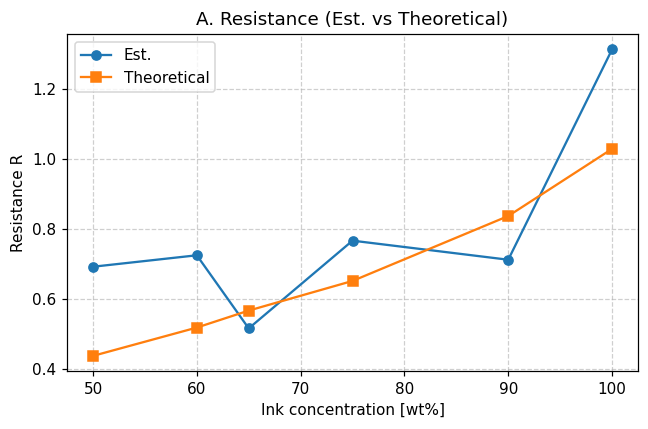

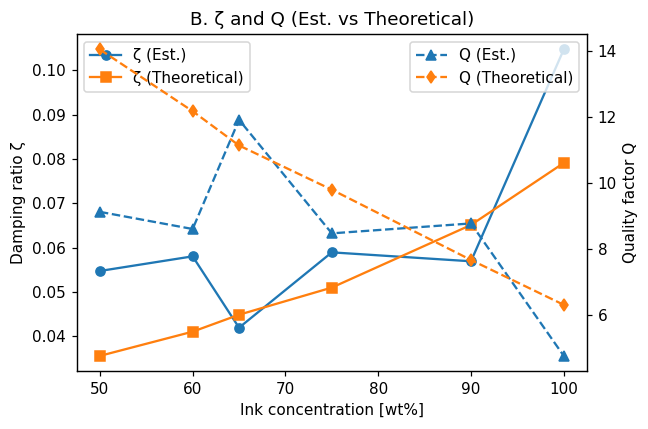

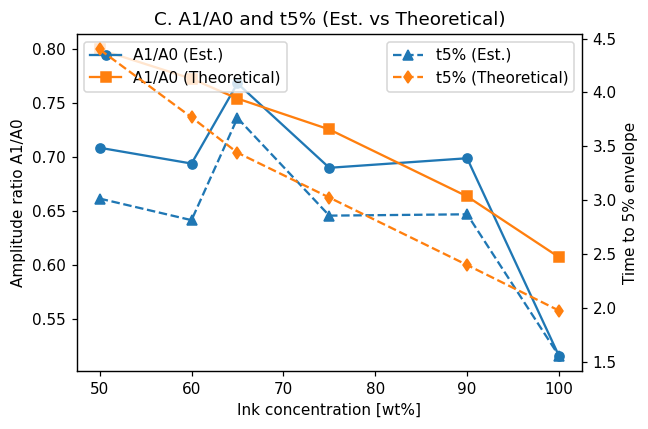

CSV 파일이 저장되었습니다: D:\lsy_DL\Paper result


In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# -----------------------------
# 1) Raw data 입력
# -----------------------------
# (A) 추론값 (Est.)
raw_est = [
    ("EG 100",100, 1.313, 0.3404, 0.008659),
    ("EG 90", 90, 0.7123, 0.3410, 0.008715),
    ("EG 75", 75, 0.7668, 0.3655, 0.008641),
    ("EG 65", 65, 0.5161, 0.3241, 0.008569),
    ("EG 60", 60, 0.7250, 0.3405, 0.008732),
    ("EG 50", 50, 0.6923, 0.3483, 0.008714),
]

# (B) 이론값 (Theoretical)
raw_theo = [
    ("EG 100",100, 1.029, 0.3390, 0.008016),
    ("EG 90", 90, 0.8372, 0.3350, 0.008111),
    ("EG 75", 75, 0.6517, 0.3289, 0.008059),
    ("EG 65", 65, 0.5670, 0.3256, 0.008161),
    ("EG 60", 60, 0.5185, 0.3262, 0.008184),
    ("EG 50", 50, 0.4376, 0.3213, 0.008507),
]

# -----------------------------
# 2) 지표 계산 함수 정의
# -----------------------------
def compute_metrics(raw):
    df = pd.DataFrame(raw, columns=["composition","EG_wt_pct","R","L","C"])
    df = df.sort_values("EG_wt_pct").reset_index(drop=True)
    df["alpha"] = df["R"] / (2.0*df["L"])
    df["omega0"] = 1.0 / np.sqrt(df["L"]*df["C"])
    df["zeta"] = df["alpha"] / df["omega0"]
    df["Q"] = 1.0 / (2.0*df["zeta"])
    tmp = np.maximum(df["omega0"]**2 - df["alpha"]**2, 0.0)
    df["omega_d"] = np.sqrt(tmp)
    df["log_dec"] = 2.0*np.pi*df["zeta"] / np.sqrt(np.maximum(1.0 - df["zeta"]**2, 1e-12))
    df["A1_over_A0"] = np.exp(-df["log_dec"])
    df["t_5pct_envelope"] = np.log(20.0) / df["alpha"]
    df["pole_real"] = -df["alpha"]
    df["pole_imag"] = df["omega_d"]
    return df

df_est  = compute_metrics(raw_est)
df_theo = compute_metrics(raw_theo)

# -----------------------------
# 3) 시각화
# -----------------------------
x = df_est["EG_wt_pct"].values

# (A) Resistance
plt.figure(figsize=(6,4))
plt.plot(x, df_est["R"], marker="o", label="Est.")
plt.plot(x, df_theo["R"], marker="s", label="Theoretical")
plt.xlabel("Ink concentration [wt%]")
plt.ylabel("Resistance R")
plt.title("A. Resistance (Est. vs Theoretical)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# (B) ζ and Q
fig, ax1 = plt.subplots(figsize=(6,4))
ax1.plot(x, df_est["zeta"], marker="o", label="ζ (Est.)")
ax1.plot(x, df_theo["zeta"], marker="s", label="ζ (Theoretical)")
ax1.set_xlabel("Ink concentration [wt%]")
ax1.set_ylabel("Damping ratio ζ")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(x, df_est["Q"], marker="^", linestyle="--", label="Q (Est.)")
ax2.plot(x, df_theo["Q"], marker="d", linestyle="--", label="Q (Theoretical)")
ax2.set_ylabel("Quality factor Q")
ax2.legend(loc="upper right")

plt.title("B. ζ and Q (Est. vs Theoretical)")
plt.tight_layout()
plt.show()

# (C) Amplitude ratio & t5%
fig, ax1 = plt.subplots(figsize=(6,4))
ax1.plot(x, df_est["A1_over_A0"], marker="o", label="A1/A0 (Est.)")
ax1.plot(x, df_theo["A1_over_A0"], marker="s", label="A1/A0 (Theoretical)")
ax1.set_xlabel("Ink concentration [wt%]")
ax1.set_ylabel("Amplitude ratio A1/A0")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(x, df_est["t_5pct_envelope"], marker="^", linestyle="--", label="t5% (Est.)")
ax2.plot(x, df_theo["t_5pct_envelope"], marker="d", linestyle="--", label="t5% (Theoretical)")
ax2.set_ylabel("Time to 5% envelope")
ax2.legend(loc="upper right")

plt.title("C. A1/A0 and t5% (Est. vs Theoretical)")
plt.tight_layout()
plt.show()


# -----------------------------
# 4) CSV 저장
# -----------------------------
save_dir = r"D:\lsy_DL\Paper result"
os.makedirs(save_dir, exist_ok=True)

df_est.to_csv(os.path.join(save_dir, "RLC_metrics_Est.csv"), index=False)
df_theo.to_csv(os.path.join(save_dir, "RLC_metrics_Theoretical.csv"), index=False)

print("CSV 파일이 저장되었습니다:", save_dir)
